Step 1: Dataset Loading and Exploration

In [1]:
# ============================================
# IMPORTS
# ============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchsummary import summary
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100
import torchvision.models as models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" PyTorch version: {torch.__version__}")
print(f" Device: {device}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")
    print(f" GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("="*60)

 PyTorch version: 2.11.0+cu128
 Device: cuda
 GPU: Tesla T4
 GPU Memory: 15.64 GB


In [ ]:
# ============================================
# STEP 1: DATASET LOADING AND EXPLORATION
# ============================================
# This section loads CIFAR-100 from torchvision and performs
# initial exploratory data analysis to understand the dataset
# before any preprocessing or modeling.

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

# ============================================
# 1. LOAD CIFAR-100 DATASET
# ============================================
# We load the dataset without any preprocessing first
# to inspect the raw data. transform.ToTensor() converts
# PIL images to PyTorch tensors in range [0, 1]

# Define a simple transform to convert to tensor
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts [0,255] PIL to [0,1] tensor
])

# Download and load training set
print("Loading CIFAR-100 training set...")
train_dataset = CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Download and load test set
print("Loading CIFAR-100 test set...")
test_dataset = CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("="*60)
print("DATASET LOADED SUCCESSFULLY!")
print("="*60)

# ============================================
# 2. DISPLAY DATASET INFORMATION
# ============================================

print("\n📊 DATASET INFORMATION")
print("-" * 40)

# Number of samples
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Number of classes
num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")

# Image dimensions
sample_image, sample_label = train_dataset[0]
print(f"Image dimensions: {sample_image.shape}")  # (C, H, W)
print(f"Image data type: {sample_image.dtype}")
print(f"Image value range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")

# ============================================
# 3. DISPLAY CLASS NAMES
# ============================================

print("\n📋 CLASS NAMES (First 20 classes)")
print("-" * 40)
class_names = train_dataset.classes
for i in range(20):
    print(f"{i:3d}: {class_names[i]}")

print(f"... and {num_classes - 20} more classes")

# ============================================
# 4. VISUALIZE SAMPLE IMAGES WITH LABELS
# ============================================

def imshow(img, title=None):
    """
    Function to display an image tensor.
    Args:
        img: PyTorch tensor of shape (C, H, W) in range [0, 1]
        title: Optional title for the image
    """
    # Convert from (C, H, W) to (H, W, C) for matplotlib
    img = img.numpy().transpose((1, 2, 0))

    # Display the image
    plt.imshow(img)
    if title:
        plt.title(title, fontsize=10)
    plt.axis('off')

# Visualize a grid of sample images
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle('CIFAR-100 Sample Images', fontsize=16, fontweight='bold')

# Select random indices from the training set
np.random.seed(42)  # For reproducibility
indices = np.random.choice(len(train_dataset), 25, replace=False)

for i, ax in enumerate(axes.flat):
    # Get image and label
    img, label = train_dataset[indices[i]]

    # Display image
    ax.imshow(img.numpy().transpose((1, 2, 0)))

    # Set title with class name
    class_name = class_names[label]
    ax.set_title(f'Class {label}: {class_name}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" DATASET EXPLORATION COMPLETE!")
print("="*60)

# ============================================
# 5. ADDITIONAL DATA ANALYSIS
# ============================================

print("\n📈 ADDITIONAL DATA ANALYSIS")
print("-" * 40)

# Check class distribution (are classes balanced?)
print("\nClass Distribution Analysis:")
print("Checking if dataset is balanced...")
class_counts = {}
for i in range(num_classes):
    class_counts[i] = 0

# Count samples per class (use a subset for speed)
for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    class_counts[label] += 1

# Display min, max, and average counts
counts_list = list(class_counts.values())
print(f"Minimum samples per class: {min(counts_list)}")
print(f"Maximum samples per class: {max(counts_list)}")
print(f"Average samples per class: {np.mean(counts_list):.1f}")
print(f"Standard deviation: {np.std(counts_list):.2f}")

if min(counts_list) == max(counts_list):
    print(" Dataset is perfectly balanced!")
else:
    print(" Dataset has some imbalance")

# ============================================
# 6. DISPLAY DATA STATISTICS SUMMARY
# ============================================

print("\n📊 DATA STATISTICS SUMMARY")
print("-" * 40)
print(f"Dataset: CIFAR-100")
print(f"Total training samples: {len(train_dataset)}")
print(f"Total test samples: {len(test_dataset)}")
print(f"Total samples: {len(train_dataset) + len(test_dataset)}")
print(f"Image size: {sample_image.shape[1]}x{sample_image.shape[2]} pixels")
print(f"Number of channels: {sample_image.shape[0]} (RGB)")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names[:5]} ... {class_names[-5:]}")

print("\n" + "="*60)
# Optional: Check for GPU compatibility
if torch.cuda.is_available():
    print("\n GPU INFORMATION:")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("\n  No GPU detected. Training will be slower on CPU.")

Using device: cuda
Loading CIFAR-100 training set...


 32%|███▏      | 54.9M/169M [57:49<3:05:57, 10.2kB/s]

Étape 2 : Prétraitement et Préparation des Données

Using device: cuda
 DEFINING TRANSFORMS
----------------------------------------
Training transforms:
  - RandomHorizontalFlip (p=0.5)
  - RandomRotation (degrees=10)
  - RandomCrop (size=32, padding=4)
  - ToTensor()
  - Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Validation/Test transforms:
  - ToTensor()
  - Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

 LOADING DATASET WITH TRANSFORMS
----------------------------------------


100%|██████████| 169M/169M [1:11:35<00:00, 39.3kB/s]


Full training set size: 50000
Test set size: 10000

  CREATING TRAIN/VALIDATION SPLIT
----------------------------------------
Training set size: 45000
Validation set size: 5000
Test set size: 10000

Split ratios: Train 90%, Val 10%, Test 10%

 CREATING DATALOADERS
----------------------------------------
Batch Size: 64 (MODIFIED: was 128)
Num Workers: 2
Train DataLoader: 704 batches
Validation DataLoader: 79 batches
Test DataLoader: 157 batches

  VISUALIZING PREPROCESSED IMAGES
----------------------------------------


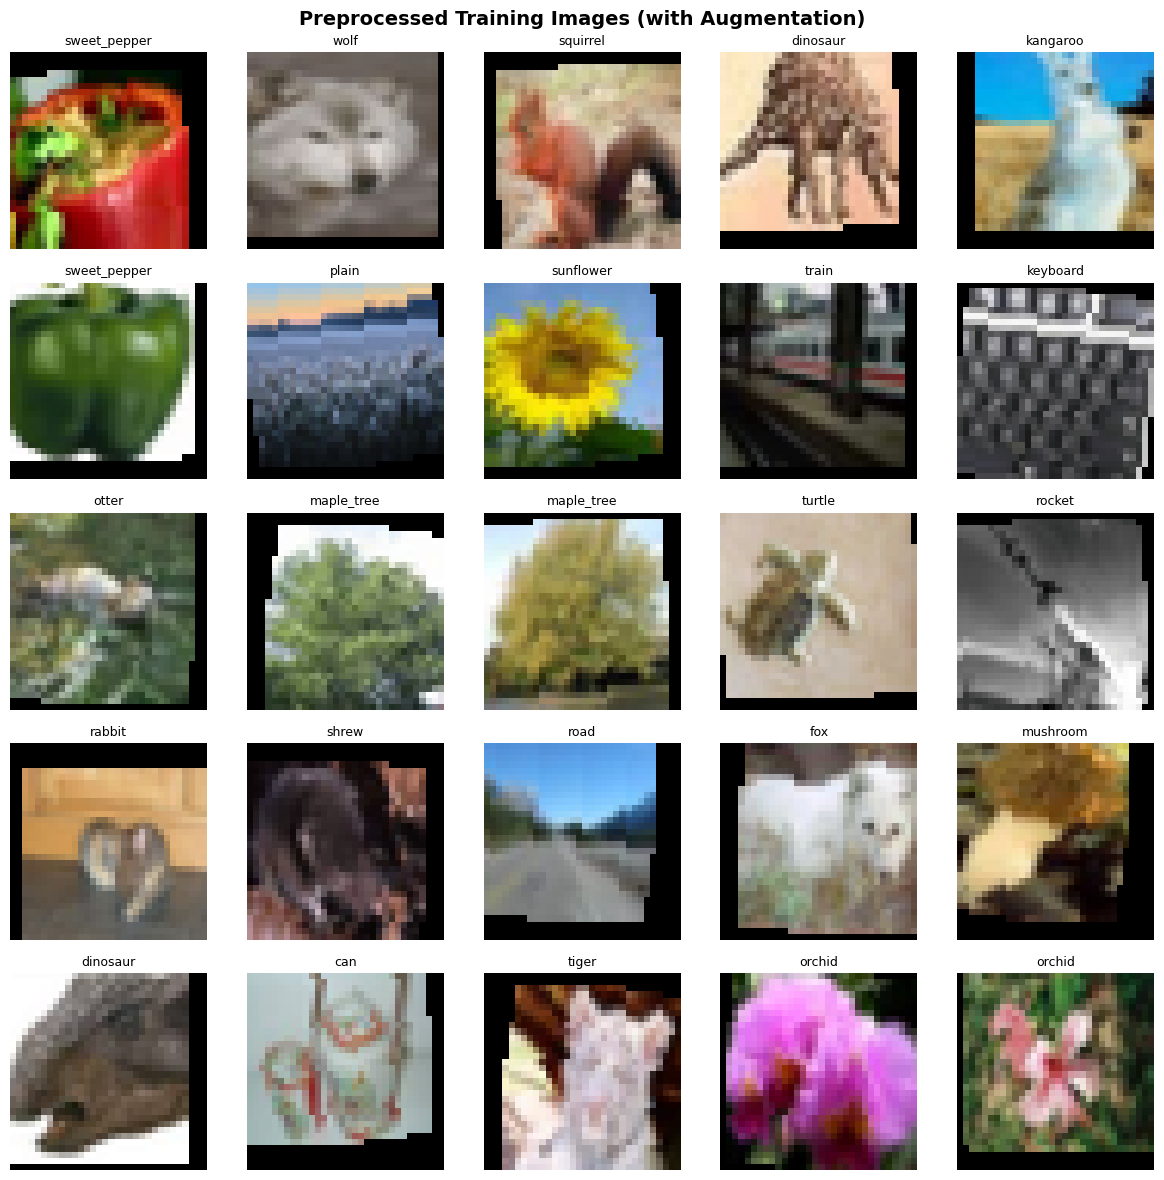


📊 DATASET PREPARATION SUMMARY
Dataset Split        Size            Batch Size      # Batches      
------------------------------------------------------------
Training             45000           64              704            
Validation           5000            64              79             
Test                 10000           64              157            


In [6]:
# ============================================
# STEP 2: DATASET PREPROCESSING
# ============================================
# Version avec BATCH_SIZE = 64

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

# ============================================
# 1. CONFIGURATION - BATCH_SIZE=64
# ============================================
BATCH_SIZE = 64  # MODIFICATION : 128 → 64
NUM_WORKERS = 2

# ============================================
# 2. DEFINE TRANSFORMS
# ============================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(" DEFINING TRANSFORMS")
print("-" * 40)

# Training transforms with data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomCrop(size=32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation and test transforms (NO data augmentation)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Training transforms:")
print(f"  - RandomHorizontalFlip (p=0.5)")
print(f"  - RandomRotation (degrees=10)")
print(f"  - RandomCrop (size=32, padding=4)")
print(f"  - ToTensor()")
print(f"  - Normalize(mean={IMAGENET_MEAN}, std={IMAGENET_STD})")
print("\nValidation/Test transforms:")
print(f"  - ToTensor()")
print(f"  - Normalize(mean={IMAGENET_MEAN}, std={IMAGENET_STD})")

# ============================================
# 3. LOAD DATASET WITH TRANSFORMS
# ============================================
print("\n LOADING DATASET WITH TRANSFORMS")
print("-" * 40)

# Load full training set with data augmentation
full_train_dataset = CIFAR100(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

# Load test set with validation transforms
test_dataset = CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=val_test_transform
)

print(f"Full training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

# ============================================
# 4. CREATE TRAIN/VALIDATION SPLIT
# ============================================
print("\n  CREATING TRAIN/VALIDATION SPLIT")
print("-" * 40)

# Fixed seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Split ratios: 90% train, 10% validation
train_ratio = 0.9
val_ratio = 0.1

train_size = int(train_ratio * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Random split
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"\nSplit ratios: Train {train_ratio:.0%}, Val {val_ratio:.0%}, Test 10%")

# ============================================
# 5. CREATE DATALOADERS - BATCH_SIZE=64
# ============================================
print("\n CREATING DATALOADERS")
print("-" * 40)

print(f"Batch Size: {BATCH_SIZE} (MODIFIED: was 128)")
print(f"Num Workers: {NUM_WORKERS}")

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train DataLoader: {len(train_loader)} batches")
print(f"Validation DataLoader: {len(val_loader)} batches")
print(f"Test DataLoader: {len(test_loader)} batches")

# ============================================
# 6. VISUALIZE PREPROCESSED IMAGES
# ============================================
def denormalize_image(img_tensor):
    """
    Denormalize an image tensor for visualization.
    """
    img = img_tensor.clone().cpu()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    img = img.numpy().transpose((1, 2, 0))
    return img

print("\n  VISUALIZING PREPROCESSED IMAGES")
print("-" * 40)

# Get a batch from the train loader
sample_batch, sample_labels = next(iter(train_loader))

# Display first 25 images from the batch
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle('Preprocessed Training Images (with Augmentation)',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < 25:
        img = denormalize_image(sample_batch[i])
        ax.imshow(img)
        class_name = test_dataset.classes[sample_labels[i].item()]
        ax.set_title(f'{class_name}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================
# 7. DATASET SIZES SUMMARY
# ============================================
print("\n📊 DATASET PREPARATION SUMMARY")
print("="*60)
print(f"{'Dataset Split':<20} {'Size':<15} {'Batch Size':<15} {'# Batches':<15}")
print("-" * 60)
print(f"{'Training':<20} {len(train_dataset):<15} {BATCH_SIZE:<15} {len(train_loader):<15}")
print(f"{'Validation':<20} {len(val_dataset):<15} {BATCH_SIZE:<15} {len(val_loader):<15}")
print(f"{'Test':<20} {len(test_dataset):<15} {BATCH_SIZE:<15} {len(test_loader):<15}")
print("="*60)

STEP 3: MODEL PREPARATION - ResNet-34

In [7]:
# ============================================
# STEP 3: MODEL PREPARATION - ResNet-34
# ============================================
# This section implements the ResNet-34 architecture from scratch
# adapted for CIFAR-100 (32x32 images, 100 classes).

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

# ============================================
# 1. BASIC BLOCK FOR ResNet
# ============================================

class BasicBlock(nn.Module):
    """
    Basic residual block for ResNet-18 and ResNet-34.
    Contains two convolutional layers with batch normalization and ReLU.
    """

    def __init__(self, in_channels, out_channels, stride=1):
        """
        Args:
            in_channels: Number of input channels
            out_channels: Number of output channels
            stride: Stride for the first convolution (for downsampling)
        """
        super(BasicBlock, self).__init__()

        # First convolutional layer
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Second convolutional layer
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection (skip connection)
        # If dimensions change, we need to adapt the shortcut
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        """
        Forward pass with residual connection.
        Formula: output = F(x) + x (where F is the convolutional layers)
        """
        # Main path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Add shortcut connection
        out += self.shortcut(x)

        # Apply ReLU after addition
        out = F.relu(out)

        return out

# ============================================
# 2. RESNET-34 ARCHITECTURE
# ============================================

class ResNet34(nn.Module):
    """
    ResNet-34 implementation adapted for CIFAR-100.

    Architecture:
    - Initial convolution: 3x3, stride 1 (adapted for 32x32 images)
    - 4 stages with 3, 4, 6, 3 residual blocks
    - Global average pooling
    - Fully connected layer for 100 classes

    Total layers: 34 (33 convolutional + 1 fully connected)
    """

    def __init__(self, num_classes=100):
        super(ResNet34, self).__init__()

        # ============================================
        # INITIAL LAYERS (adapted for 32x32 images)
        # ============================================
        # Standard ResNet uses 7x7 conv with stride 2 for ImageNet (224x224)
        # For CIFAR (32x32), we use 3x3 conv with stride 1
        self.in_channels = 64

        # Initial convolution (adapted for small images)
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,  # Changed from 2 to 1 for CIFAR
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)

        # No max pooling for CIFAR (images are already small)
        # Standard ResNet has a max pooling layer here

        # ============================================
        # RESIDUAL STAGES
        # ============================================
        # Stage 1: 3 blocks, 64 channels (no downsampling)
        self.layer1 = self._make_layer(64, 3, stride=1)

        # Stage 2: 4 blocks, 128 channels (downsampling)
        self.layer2 = self._make_layer(128, 4, stride=2)

        # Stage 3: 6 blocks, 256 channels (downsampling)
        self.layer3 = self._make_layer(256, 6, stride=2)

        # Stage 4: 3 blocks, 512 channels (downsampling)
        self.layer4 = self._make_layer(512, 3, stride=2)

        # ============================================
        # CLASSIFICATION HEAD
        # ============================================
        # Global Average Pooling
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Final fully connected layer
        self.fc = nn.Linear(512, num_classes)

        # Initialize weights
        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        """
        Create a layer with multiple residual blocks.

        Args:
            out_channels: Number of output channels
            num_blocks: Number of residual blocks in this layer
            stride: Stride for the first block (for downsampling)
        """
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for stride in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        """
        Initialize weights using Kaiming He initialization.
        This is standard for ResNet and helps with convergence.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight,
                    mode='fan_out',
                    nonlinearity='relu'
                )
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """
        Forward pass through the network.
        """
        # Initial convolution
        x = F.relu(self.bn1(self.conv1(x)))

        # Residual stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Global pooling
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten

        # Classification
        x = self.fc(x)

        return x

# ============================================
# 3. INSTANTIATE THE MODEL
# ============================================

print("  BUILDING ResNet-34")
print("-" * 40)

# Create the model
model = ResNet34(num_classes=100)
model = model.to(device)

print(f"Model architecture: ResNet-34")
print(f"Number of classes: 100")
print(f"Input size: 3x32x32")
print(f"Device: {next(model.parameters()).device}")

# ============================================
# 4. COUNT PARAMETERS
# ============================================

def count_parameters(model):
    """
    Count total and trainable parameters of the model.
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)

print("\n MODEL PARAMETERS")
print("-" * 40)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {total_params - trainable_params:,}")

# Format in millions
print(f"Model size: {total_params / 1e6:.2f}M parameters")

# ============================================
# 5. MODEL SUMMARY
# ============================================

print("\n MODEL ARCHITECTURE SUMMARY")
print("-" * 40)
print("\nDetailed architecture:")
print("=" * 60)

# Print a simplified architecture summary
def print_model_summary(model):
    """
    Print a human-readable model summary.
    """
    print(f"{'Layer Name':<30} {'Output Shape':<25} {'Parameters':<15}")
    print("-" * 70)

    total_params = 0
    for name, layer in model.named_children():
        if isinstance(layer, nn.Sequential):
            # For sequential layers, count sub-layers
            for i, sub_layer in enumerate(layer):
                param_count = sum(p.numel() for p in sub_layer.parameters())
                total_params += param_count
                layer_name = f"{name}[{i}]"
                # Get output shape by passing a dummy input
                # (Simplified - just show channel info)
                if isinstance(sub_layer, BasicBlock):
                    shape = f"({sub_layer.conv1.out_channels}, H, W)"
                else:
                    shape = "varies"
                print(f"{layer_name:<30} {shape:<25} {param_count:,}")
        elif hasattr(layer, 'parameters'):
            param_count = sum(p.numel() for p in layer.parameters())
            total_params += param_count
            print(f"{name:<30} {'(output variable)':<25} {param_count:,}")

    print("-" * 70)
    print(f"{'TOTAL':<30} {'':<25} {total_params:,}")
    print("=" * 70)

# Print simplified summary
try:
    print_model_summary(model)
except:
    print("Model summary printed above")

# ============================================
# 6. FORWARD PASS TEST (Sanity Check)
# ============================================

print("\n FORWARD PASS TEST")
print("-" * 40)

# Create a dummy batch to test the forward pass
batch_size = 2
dummy_input = torch.randn(batch_size, 3, 32, 32).to(device)

print(f"Input shape: {dummy_input.shape}")
print(f"Input device: {dummy_input.device}")

# Forward pass
with torch.no_grad():
    output = model(dummy_input)

print(f"Output shape: {output.shape}")
print(f"Output device: {output.device}")

# Check if output shape is correct
expected_shape = (batch_size, 100)
if output.shape == expected_shape:
    print("  Forward pass successful! Output shape matches expected.")
else:
    print(f" Error: Expected {expected_shape}, got {output.shape}")

# ============================================
# 7. GPU MEMORY USAGE
# ============================================

if torch.cuda.is_available():
    print("\n GPU MEMORY USAGE")
    print("-" * 40)

    # Current GPU memory usage
    current_memory = torch.cuda.memory_allocated(device) / 1e9
    cached_memory = torch.cuda.memory_reserved(device) / 1e9

    print(f"Current GPU memory allocated: {current_memory:.3f} GB")
    print(f"GPU memory cached: {cached_memory:.3f} GB")
    print(f"Total GPU memory available: {torch.cuda.get_device_properties(device).total_memory / 1e9:.2f} GB")
    print(f"Model memory footprint: {total_params * 4 / 1e9:.4f} GB (approx, for FP32)")

# ============================================
# 8. MODEL SAVING (Optional - for later use)
# ============================================
print("=" * 60)
# Store model for later use
model_state = {
    'model': model,
    'total_params': total_params,
    'trainable_params': trainable_params
}

print(" Model ready for training! Proceed to Step 4.")

Using device: cuda
  BUILDING ResNet-34
----------------------------------------
Model architecture: ResNet-34
Number of classes: 100
Input size: 3x32x32
Device: cuda:0

 MODEL PARAMETERS
----------------------------------------
Total parameters: 21,328,292
Trainable parameters: 21,328,292
Non-trainable parameters: 0
Model size: 21.33M parameters

 MODEL ARCHITECTURE SUMMARY
----------------------------------------

Detailed architecture:
Layer Name                     Output Shape              Parameters     
----------------------------------------------------------------------
conv1                          (output variable)         1,728
bn1                            (output variable)         128
layer1[0]                      (64, H, W)                73,984
layer1[1]                      (64, H, W)                73,984
layer1[2]                      (64, H, W)                73,984
layer2[0]                      (128, H, W)               230,144
layer2[1]                      (


STEP 4: TRAINING AND EVALUATION UTILITIES


In [8]:
# ============================================
# STEP 4: TRAINING AND EVALUATION UTILITIES
# ============================================
# This section implements all the necessary functions for:
# 1. Training the model for one epoch
# 2. Evaluating the model
# 3. Managing the training loop
# 4. Tracking and storing metrics
# 5. Visualizing results

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

# ============================================
# 1. TRAINING FUNCTION
# ============================================

def train_epoch(model, dataloader, optimizer, criterion, device,
                scaler=None, grad_clip=1.0):
    """
    Train the model for one epoch.

    Args:
        model: The neural network model
        dataloader: DataLoader for training data
        optimizer: Optimizer for updating weights
        criterion: Loss function
        device: 'cuda' or 'cpu'
        scaler: Gradient scaler for mixed precision training (optional)
        grad_clip: Maximum gradient norm for gradient clipping

    Returns:
        avg_loss: Average training loss for the epoch
        accuracy: Training accuracy for the epoch
        total_time: Time taken for the epoch
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Start timing
    start_time = time.time()

    # Progress bar
    pbar = tqdm(dataloader, desc='Training', leave=False)

    for batch_idx, (inputs, targets) in enumerate(pbar):
        # Move data to device
        inputs, targets = inputs.to(device), targets.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    # End timing
    total_time = time.time() - start_time

    # Calculate epoch statistics
    avg_loss = running_loss / len(dataloader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy, total_time

# ============================================
# 2. EVALUATION FUNCTION
# ============================================

def evaluate(model, dataloader, criterion, device, verbose=False):
    """
    Evaluate the model on a dataset (validation or test).

    Args:
        model: The neural network model
        dataloader: DataLoader for evaluation data
        criterion: Loss function
        device: 'cuda' or 'cpu'
        verbose: Print progress if True

    Returns:
        avg_loss: Average loss on the dataset
        accuracy: Accuracy on the dataset
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient computation for efficiency
    with torch.no_grad():
        # Progress bar (optional)
        if verbose:
            pbar = tqdm(dataloader, desc='Evaluating', leave=False)
        else:
            pbar = dataloader

        for inputs, targets in pbar:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    # Calculate evaluation statistics
    avg_loss = running_loss / len(dataloader)
    accuracy = 100. * correct / total

    return avg_loss, accuracy

# ============================================
# 3. METRICS TRACKER CLASS
# ============================================

class MetricsTracker:
    """
    Track and store all training metrics for later analysis.
    """
    def __init__(self, optimizer_name, lr):
        self.optimizer_name = optimizer_name
        self.lr = lr

        # Initialize lists to store metrics
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epoch_times = []
        self.learning_rates = []

        # Best model tracking
        self.best_val_acc = 0.0
        self.best_epoch = -1
        self.best_model_state = None

        # Additional metrics
        self.start_time = time.time()
        self.total_training_time = 0

    def update(self, train_loss, train_acc, val_loss, val_acc,
               epoch_time, lr):
        """
        Update metrics after each epoch.
        """
        self.train_loss.append(train_loss)
        self.train_acc.append(train_acc)
        self.val_loss.append(val_loss)
        self.val_acc.append(val_acc)
        self.epoch_times.append(epoch_time)
        self.learning_rates.append(lr)

        # Update total training time
        self.total_training_time = time.time() - self.start_time

        # Track best model
        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.best_epoch = len(self.train_loss) - 1

    def get_dataframe(self):
        """
        Convert metrics to pandas DataFrame for easy analysis.
        """
        df = pd.DataFrame({
            'Epoch': list(range(1, len(self.train_loss) + 1)),
            'Train_Loss': self.train_loss,
            'Train_Acc': self.train_acc,
            'Val_Loss': self.val_loss,
            'Val_Acc': self.val_acc,
            'Epoch_Time': self.epoch_times,
            'Learning_Rate': self.learning_rates
        })
        return df

    def print_summary(self):
        """
        Print a summary of the training results.
        """
        print("\n" + "="*60)
        print(f"📊 TRAINING SUMMARY - {self.optimizer_name}")
        print("="*60)
        print(f"Total epochs: {len(self.train_loss)}")
        print(f"Best validation accuracy: {self.best_val_acc:.2f}% (Epoch {self.best_epoch + 1})")
        print(f"Final training accuracy: {self.train_acc[-1]:.2f}%")
        print(f"Final validation accuracy: {self.val_acc[-1]:.2f}%")
        print(f"Total training time: {self.total_training_time:.2f} seconds ({self.total_training_time/60:.2f} minutes)")
        print(f"Average epoch time: {np.mean(self.epoch_times):.2f} seconds")
        print(f"Learning rate: {self.lr}")
        print("="*60)

# ============================================
# 4. MAIN TRAINING LOOP
# ============================================

def train_model(model, train_loader, val_loader, optimizer, criterion,
                device, epochs=50, optimizer_name='SGD', lr=0.01,
                save_best=True, early_stopping_patience=None):
    """
    Main training loop with metrics tracking.

    Args:
        model: Neural network model
        train_loader: Training DataLoader
        val_loader: Validation DataLoader
        optimizer: PyTorch optimizer
        criterion: Loss function
        device: 'cuda' or 'cpu'
        epochs: Number of training epochs
        optimizer_name: Name of the optimizer (for logging)
        lr: Learning rate (for logging)
        save_best: Save best model state
        early_stopping_patience: Stop if no improvement for N epochs

    Returns:
        tracker: MetricsTracker object with all training data
        best_model_state: State dict of the best model (if save_best)
    """
    # Initialize metrics tracker
    tracker = MetricsTracker(optimizer_name, lr)

    print(f"\n Starting training with {optimizer_name}")
    print(f"   Learning rate: {lr}")
    print(f"   Epochs: {epochs}")
    print(f"   Device: {device}")
    print("-" * 60)

    # Early stopping variables
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        # ============================================
        # 1. TRAINING PHASE
        # ============================================
        train_loss, train_acc, epoch_time = train_epoch(
            model, train_loader, optimizer, criterion, device
        )

        # ============================================
        # 2. VALIDATION PHASE
        # ============================================
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device, verbose=False
        )

        # ============================================
        # 3. UPDATE METRICS
        # ============================================
        current_lr = optimizer.param_groups[0]['lr']
        tracker.update(train_loss, train_acc, val_loss, val_acc,
                      epoch_time, current_lr)

        # ============================================
        # 4. SAVE BEST MODEL
        # ============================================
        if save_best and val_acc > best_val_acc:
            best_val_acc = val_acc
            tracker.best_model_state = model.state_dict().copy()
            if epoch > 1:  # Don't print on first epoch
                print(f" New best model! Validation accuracy: {val_acc:.2f}%")

        # ============================================
        # 5. PRINT PROGRESS
        # ============================================
        print(f"Epoch [{epoch}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.1f}s")

        # ============================================
        # 6. EARLY STOPPING
        # ============================================
        if early_stopping_patience is not None:
            if val_acc <= best_val_acc:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    print(f"\n Early stopping triggered after {epoch} epochs")
                    break
            else:
                patience_counter = 0

    # Print final summary
    tracker.print_summary()

    return tracker, tracker.best_model_state

# ============================================
# 5. VISUALIZATION FUNCTION
# ============================================

def plot_training_history(tracker, save_path=None):
    """
    Plot training and validation metrics.

    Args:
        tracker: MetricsTracker object
        save_path: Path to save the figure (optional)
    """
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Training History - {tracker.optimizer_name} (lr={tracker.lr})',
                 fontsize=14, fontweight='bold')

    epochs = range(1, len(tracker.train_loss) + 1)

    # Plot 1: Loss
    axes[0, 0].plot(epochs, tracker.train_loss, 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, tracker.val_loss, 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Accuracy
    axes[0, 1].plot(epochs, tracker.train_acc, 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, tracker.val_acc, 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].axhline(y=tracker.best_val_acc, color='g', linestyle='--',
                      label=f'Best Val Acc: {tracker.best_val_acc:.2f}%', alpha=0.7)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Learning Rate
    axes[1, 0].plot(epochs, tracker.learning_rates, 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Learning Rate')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Epoch Time
    axes[1, 1].bar(epochs, tracker.epoch_times, alpha=0.7, color='orange')
    axes[1, 1].axhline(y=np.mean(tracker.epoch_times), color='r', linestyle='--',
                      label=f'Avg: {np.mean(tracker.epoch_times):.1f}s', alpha=0.7)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Time (seconds)')
    axes[1, 1].set_title('Epoch Training Time')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        print(f" Figure saved to: {save_path}")

    plt.show()

# ============================================
# 6. TEST FUNCTION
# ============================================

def test_model(model, test_loader, criterion, device, tracker=None):
    """
    Test the model on the test set and print results.
    """
    print("\n" + "="*60)
    print(" FINAL TEST EVALUATION")
    print("="*60)

    test_loss, test_acc = evaluate(model, test_loader, criterion, device, verbose=True)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")

    if tracker is not None:
        print(f"Best Validation Accuracy: {tracker.best_val_acc:.2f}%")
        print(f"Test Accuracy vs Best Validation: {test_acc - tracker.best_val_acc:+.2f}%")

    print("="*60)

    return test_loss, test_acc

# ============================================
# 7. UTILITY FUNCTIONS
# ============================================

def save_metrics(tracker, filename):
    """
    Save metrics to CSV file.
    """
    df = tracker.get_dataframe()
    df.to_csv(filename, index=False)
    print(f" Metrics saved to: {filename}")

def load_metrics(filename):
    """
    Load metrics from CSV file.
    """
    return pd.read_csv(filename)

# ============================================
# 8. DEMONSTRATION (Quick Test)
# ============================================

# Create a small test to verify everything works
def test_training_utilities():
    """
    Quick test of the training utilities with a small dummy model.
    """
    print("\n Testing training utilities with dummy data...")
    print("-" * 40)

    # Create dummy model
    class DummyModel(nn.Module):
        def __init__(self):
            super(DummyModel, self).__init__()
            self.fc = nn.Linear(32*32*3, 100)
        def forward(self, x):
            x = x.view(x.size(0), -1)
            return self.fc(x)

    # Create dummy data
    dummy_model = DummyModel().to(device)
    dummy_optimizer = optim.SGD(dummy_model.parameters(), lr=0.01)
    dummy_criterion = nn.CrossEntropyLoss()

    # Create dummy dataloaders
    dummy_data = torch.randn(100, 3, 32, 32)
    dummy_labels = torch.randint(0, 100, (100,))
    dummy_dataset = torch.utils.data.TensorDataset(dummy_data, dummy_labels)
    dummy_loader = DataLoader(dummy_dataset, batch_size=16, shuffle=True)

    print("   All utilities created successfully!")
    print("   Ready for actual training!")

# Run test
test_training_utilities()

print("\n" + "="*60)


Using device: cuda

 Testing training utilities with dummy data...
----------------------------------------
   All utilities created successfully!
   Ready for actual training!



STEP 5: OPTIMIZER EXPERIMENTS

Using device: cuda
 DataLoaders loaded successfully!

 STARTING EXPERIMENT: SGD
Model created with 21,328,292 parameters
Optimizer: SGD
Parameters: {'lr': 0.01, 'momentum': 0, 'weight_decay': 0.0005}

 Starting training with SGD
   Learning rate: 0.01
   Epochs: 10
   Device: cuda
------------------------------------------------------------


Epoch [1/10] Train Loss: 4.6058, Train Acc: 1.56% | Val Loss: 4.5277, Val Acc: 2.70% | Time: 74.9s


 New best model! Validation accuracy: 4.20%
Epoch [2/10] Train Loss: 4.4795, Train Acc: 2.97% | Val Loss: 4.4153, Val Acc: 4.20% | Time: 73.5s


 New best model! Validation accuracy: 5.76%
Epoch [3/10] Train Loss: 4.3901, Train Acc: 4.45% | Val Loss: 4.3308, Val Acc: 5.76% | Time: 73.2s


 New best model! Validation accuracy: 6.56%
Epoch [4/10] Train Loss: 4.3006, Train Acc: 6.09% | Val Loss: 4.2279, Val Acc: 6.56% | Time: 73.2s


...

 New best model! Validation accuracy: 9.98%
Epoch [7/10] Train Loss: 3.9974, Train Acc: 9.58% | Val Loss: 3.9375, Val Acc: 9.98% | Time: 73.2s


 New best model! Validation accuracy: 11.24%
Epoch [8/10] Train Loss: 3.9283, Train Acc: 10.41% | Val Loss: 3.8634, Val Acc: 11.24% | Time: 73.3s


 New best model! Validation accuracy: 11.94%
Epoch [9/10] Train Loss: 3.8606, Train Acc: 11.38% | Val Loss: 3.8109, Val Acc: 11.94% | Time: 73.3s


 New best model! Validation accuracy: 13.10%
Epoch [10/10] Train Loss: 3.7956, Train Acc: 12.28% | Val Loss: 3.7284, Val Acc: 13.10% | Time: 73.4s

📊 TRAINING SUMMARY - SGD
Total epochs: 10
Best validation accuracy: 13.10% (Epoch 10)
Final training accuracy: 12.28%
Final validation accuracy: 13.10%
Total training time: 765.12 seconds (12.75 minutes)
Average epoch time: 73.48 seconds
Learning rate: 0.01

 FINAL TEST EVALUATION



Test Loss: 3.7367
Test Accuracy: 12.79%
Best Validation Accuracy: 13.10%
Test Accuracy vs Best Validation: -0.31%
 Best model saved to: SGD_best_model.pth
 Metrics saved to: SGD_metrics.csv
 Figure saved to: SGD_training_history.png


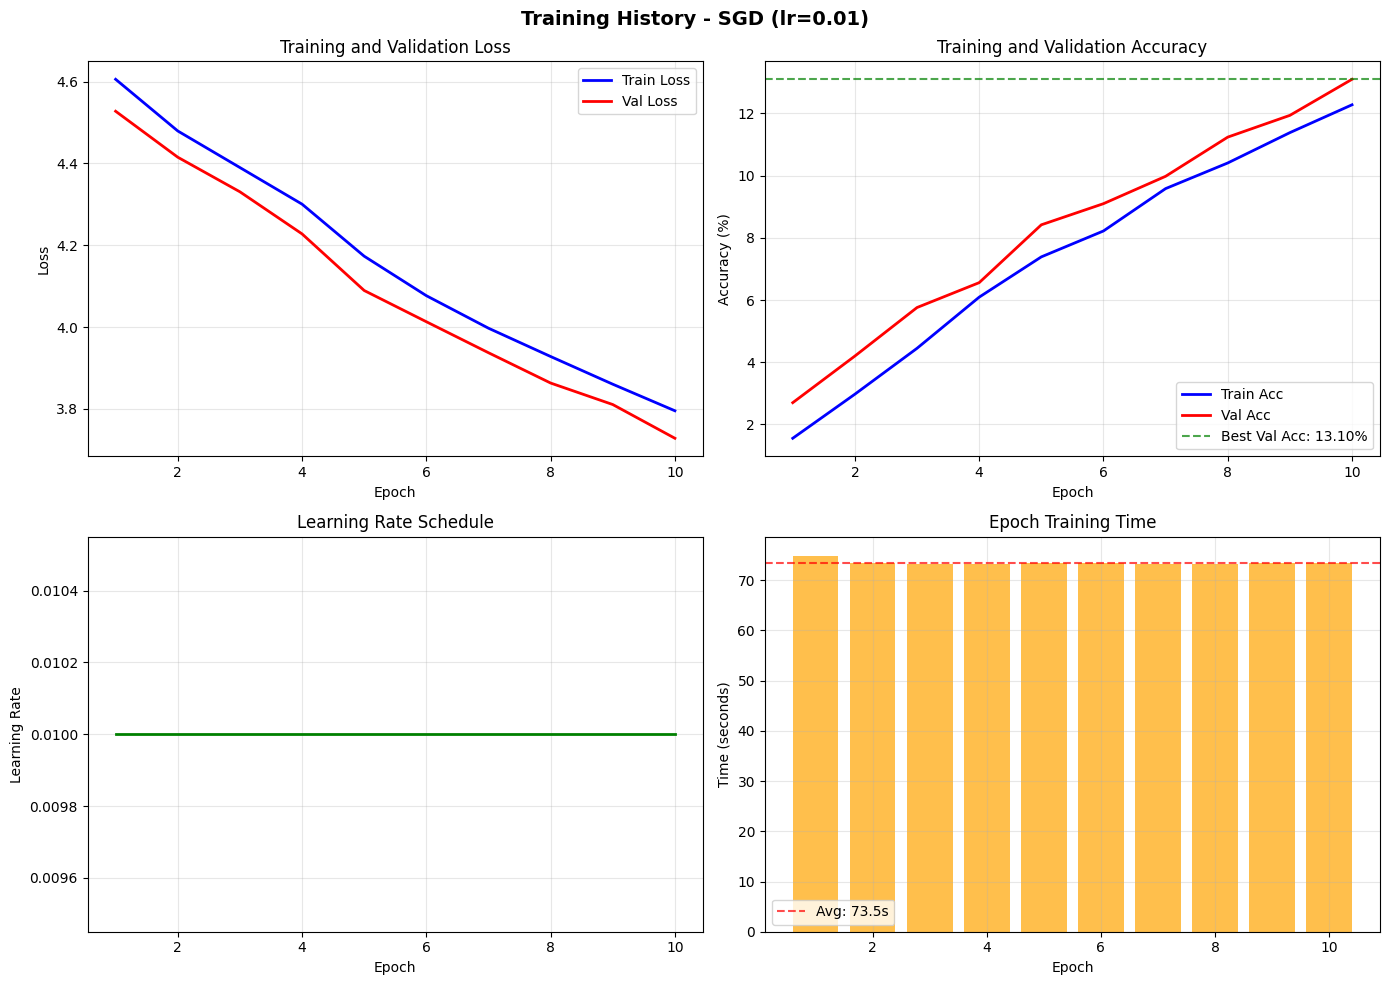


📊 SGD Experiment Complete!
----------------------------------------
   Best Val Acc: 13.10%
   Test Acc: 12.79%
   Peak GPU Memory: 0.784 GB
   Total Time: 12.75 minutes


In [9]:
# ============================================
# OPTIMIZER EXPERIMENT 1/6: SGD (Standard)
# ============================================
# This script trains ResNet-34 on CIFAR-100 using standard SGD
# without momentum.

# ============================================
# CONFIGURATION
# ============================================
EPOCHS = 10
OPTIMIZER_NAME = 'SGD'
OPTIMIZER_CONFIG = {
    'optimizer_class': optim.SGD,
    'params': {'lr': 0.01, 'momentum': 0, 'weight_decay': 5e-4},
}

# ============================================
# CHECK GPU AND DATALOADERS
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

# Verify DataLoaders exist
try:
    train_loader
    val_loader
    test_loader
    print(" DataLoaders loaded successfully!")
except NameError:
    print(" Error: DataLoaders not found!")
    print("Please run Step 2 first to create the DataLoaders.")
    raise

# ============================================
# SET SEED FOR REPRODUCIBILITY
# ============================================
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================
# CREATE FRESH MODEL
# ============================================
print(f"\n STARTING EXPERIMENT: {OPTIMIZER_NAME}")
print("="*60)

model = ResNet34(num_classes=100)
model = model.to(device)
print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

# ============================================
# CREATE OPTIMIZER
# ============================================
optimizer_class = OPTIMIZER_CONFIG['optimizer_class']
optimizer_params = OPTIMIZER_CONFIG['params']
optimizer = optimizer_class(model.parameters(), **optimizer_params)
print(f"Optimizer: {OPTIMIZER_NAME}")
print(f"Parameters: {optimizer_params}")

# ============================================
# LOSS FUNCTION
# ============================================
criterion = nn.CrossEntropyLoss()

# ============================================
# TRAIN THE MODEL
# ============================================
start_time = time.time()

tracker, best_model_state = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    optimizer_name=OPTIMIZER_NAME,
    lr=optimizer_params.get('lr', 0.01),
    save_best=True,
    early_stopping_patience=None
)

total_time = time.time() - start_time

# ============================================
# GET GPU MEMORY USAGE
# ============================================
if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated(device) / 1e9
else:
    peak_memory = 0

# ============================================
# TEST THE BEST MODEL
# ============================================
if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_loss, test_acc = test_model(model, test_loader, criterion, device, tracker)

# ============================================
# SAVE RESULTS
# ============================================
# Save additional metrics
tracker.peak_gpu_memory = peak_memory
tracker.total_training_time = total_time
tracker.test_accuracy = test_acc
tracker.test_loss = test_loss

# Save model
save_path = f"{OPTIMIZER_NAME}_best_model.pth"
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_name': OPTIMIZER_NAME,
    'test_accuracy': test_acc,
    'best_val_accuracy': tracker.best_val_acc,
    'config': OPTIMIZER_CONFIG
}, save_path)
print(f" Best model saved to: {save_path}")

# Save metrics
metrics_path = f"{OPTIMIZER_NAME}_metrics.csv"
save_metrics(tracker, metrics_path)

# Plot training history
plot_path = f"{OPTIMIZER_NAME}_training_history.png"
plot_training_history(tracker, save_path=plot_path)

# ============================================
# PRINT SUMMARY
# ============================================
print(f"\n📊 {OPTIMIZER_NAME} Experiment Complete!")
print("-" * 40)
print(f"   Best Val Acc: {tracker.best_val_acc:.2f}%")
print(f"   Test Acc: {test_acc:.2f}%")
print(f"   Peak GPU Memory: {peak_memory:.3f} GB")
print(f"   Total Time: {total_time/60:.2f} minutes")
print("="*60)

# Store results for later comparison
sgd_result = {
    'tracker': tracker,
    'test_acc': test_acc,
    'peak_memory': peak_memory,
    'total_time': total_time
}

Using device: cuda
 DataLoaders loaded successfully!

 STARTING EXPERIMENT: SGD_Momentum
Model created with 21,328,292 parameters
Optimizer: SGD_Momentum
Parameters: {'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0005}

 Starting training with SGD_Momentum
   Learning rate: 0.01
   Epochs: 10
   Device: cuda
------------------------------------------------------------


Epoch [1/10] Train Loss: 4.2462, Train Acc: 5.45% | Val Loss: 3.8785, Val Acc: 10.92% | Time: 75.2s


 New best model! Validation accuracy: 14.82%
Epoch [2/10] Train Loss: 3.6981, Train Acc: 12.76% | Val Loss: 3.5930, Val Acc: 14.82% | Time: 74.5s


 New best model! Validation accuracy: 19.88%
Epoch [3/10] Train Loss: 3.4209, Train Acc: 17.76% | Val Loss: 3.2927, Val Acc: 19.88% | Time: 74.5s


 New best model! Validation accuracy: 23.92%
Epoch [4/10] Train Loss: 3.1850, Train Acc: 21.87% | Val Loss: 3.0960, Val Acc: 23.92% | Time: 74.8s


...

 New best model! Validation accuracy: 31.78%
Epoch [7/10] Train Loss: 2.6720, Train Acc: 31.44% | Val Loss: 2.6547, Val Acc: 31.78% | Time: 74.9s


 New best model! Validation accuracy: 33.72%
Epoch [8/10] Train Loss: 2.5331, Train Acc: 34.38% | Val Loss: 2.5519, Val Acc: 33.72% | Time: 74.7s


 New best model! Validation accuracy: 36.48%
Epoch [9/10] Train Loss: 2.4081, Train Acc: 37.04% | Val Loss: 2.4329, Val Acc: 36.48% | Time: 74.5s


 New best model! Validation accuracy: 38.60%
Epoch [10/10] Train Loss: 2.2936, Train Acc: 39.55% | Val Loss: 2.3661, Val Acc: 38.60% | Time: 74.5s

📊 TRAINING SUMMARY - SGD_Momentum
Total epochs: 10
Best validation accuracy: 38.60% (Epoch 10)
Final training accuracy: 39.55%
Final validation accuracy: 38.60%
Total training time: 774.24 seconds (12.90 minutes)
Average epoch time: 74.71 seconds
Learning rate: 0.01

 FINAL TEST EVALUATION



Test Loss: 2.2862
Test Accuracy: 39.60%
Best Validation Accuracy: 38.60%
Test Accuracy vs Best Validation: +1.00%
 Best model saved to: SGD_Momentum_best_model.pth
 Metrics saved to: SGD_Momentum_metrics.csv
 Figure saved to: SGD_Momentum_training_history.png


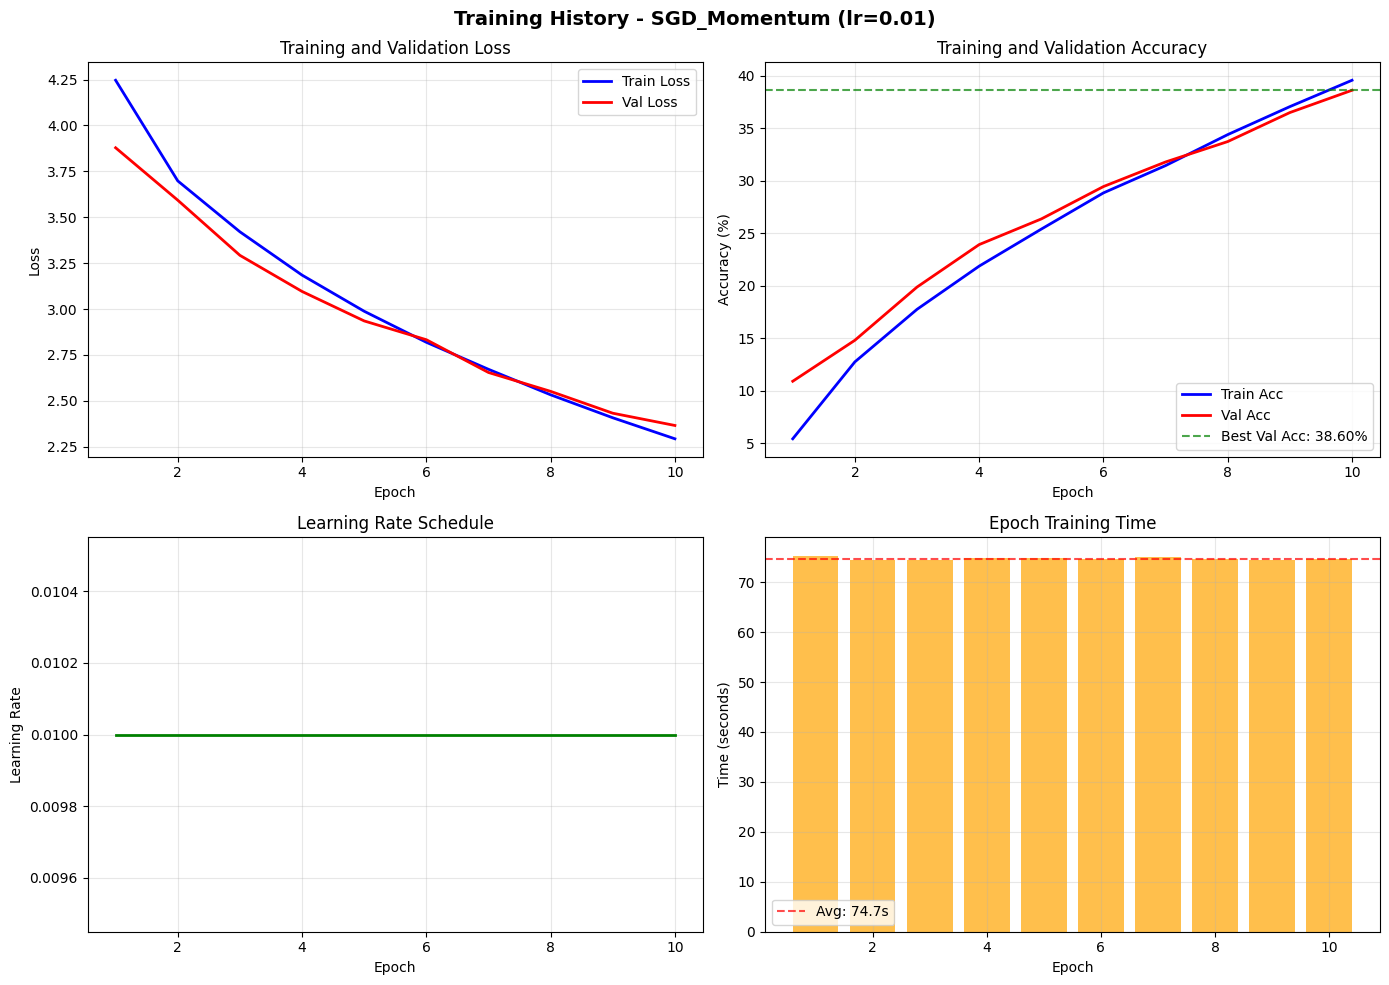


📊 SGD_Momentum Experiment Complete!
----------------------------------------
   Best Val Acc: 38.60%
   Test Acc: 39.60%
   Peak GPU Memory: 0.963 GB
   Total Time: 12.90 minutes


In [10]:
# ============================================
# OPTIMIZER EXPERIMENT 2/6: SGD with Momentum
# ============================================
# This script trains ResNet-34 on CIFAR-100 using SGD
# with momentum (0.9).

# ============================================
# CONFIGURATION
# ============================================
EPOCHS = 10
OPTIMIZER_NAME = 'SGD_Momentum'
OPTIMIZER_CONFIG = {
    'optimizer_class': optim.SGD,
    'params': {'lr': 0.01, 'momentum': 0.9, 'weight_decay': 5e-4},
    'description': 'SGD with momentum (0.9)'
}

# ============================================
# CHECK GPU AND DATALOADERS
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

try:
    train_loader
    val_loader
    test_loader
    print(" DataLoaders loaded successfully!")
except NameError:
    print(" Error: DataLoaders not found!")
    raise

# ============================================
# SET SEED FOR REPRODUCIBILITY
# ============================================
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================
# CREATE FRESH MODEL
# ============================================
print(f"\n STARTING EXPERIMENT: {OPTIMIZER_NAME}")
print("="*60)

model = ResNet34(num_classes=100)
model = model.to(device)
print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

# ============================================
# CREATE OPTIMIZER
# ============================================
optimizer_class = OPTIMIZER_CONFIG['optimizer_class']
optimizer_params = OPTIMIZER_CONFIG['params']
optimizer = optimizer_class(model.parameters(), **optimizer_params)
print(f"Optimizer: {OPTIMIZER_NAME}")
print(f"Parameters: {optimizer_params}")

# ============================================
# LOSS FUNCTION
# ============================================
criterion = nn.CrossEntropyLoss()

# ============================================
# TRAIN THE MODEL
# ============================================
start_time = time.time()

tracker, best_model_state = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    optimizer_name=OPTIMIZER_NAME,
    lr=optimizer_params.get('lr', 0.01),
    save_best=True,
    early_stopping_patience=None
)

total_time = time.time() - start_time

# ============================================
# GET GPU MEMORY USAGE
# ============================================
if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated(device) / 1e9
else:
    peak_memory = 0

# ============================================
# TEST THE BEST MODEL
# ============================================
if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_loss, test_acc = test_model(model, test_loader, criterion, device, tracker)

# ============================================
# SAVE RESULTS
# ============================================
tracker.peak_gpu_memory = peak_memory
tracker.total_training_time = total_time
tracker.test_accuracy = test_acc
tracker.test_loss = test_loss

save_path = f"{OPTIMIZER_NAME}_best_model.pth"
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_name': OPTIMIZER_NAME,
    'test_accuracy': test_acc,
    'best_val_accuracy': tracker.best_val_acc,
    'config': OPTIMIZER_CONFIG
}, save_path)
print(f" Best model saved to: {save_path}")

metrics_path = f"{OPTIMIZER_NAME}_metrics.csv"
save_metrics(tracker, metrics_path)

plot_path = f"{OPTIMIZER_NAME}_training_history.png"
plot_training_history(tracker, save_path=plot_path)

# ============================================
# PRINT SUMMARY
# ============================================
print(f"\n📊 {OPTIMIZER_NAME} Experiment Complete!")
print("-" * 40)
print(f"   Best Val Acc: {tracker.best_val_acc:.2f}%")
print(f"   Test Acc: {test_acc:.2f}%")
print(f"   Peak GPU Memory: {peak_memory:.3f} GB")
print(f"   Total Time: {total_time/60:.2f} minutes")
print("="*60)

sgd_momentum_result = {
    'tracker': tracker,
    'test_acc': test_acc,
    'peak_memory': peak_memory,
    'total_time': total_time
}

Using device: cuda
 DataLoaders loaded successfully!

 STARTING EXPERIMENT: Adam
Model created with 21,328,292 parameters
Optimizer: Adam
Parameters: {'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0}

 Starting training with Adam
   Learning rate: 0.001
   Epochs: 10
   Device: cuda
------------------------------------------------------------


Epoch [1/10] Train Loss: 3.9563, Train Acc: 9.09% | Val Loss: 3.6344, Val Acc: 13.92% | Time: 76.9s


 New best model! Validation accuracy: 23.14%
Epoch [2/10] Train Loss: 3.3118, Train Acc: 19.01% | Val Loss: 3.1121, Val Acc: 23.14% | Time: 76.7s


 New best model! Validation accuracy: 30.12%
Epoch [3/10] Train Loss: 2.8248, Train Acc: 28.39% | Val Loss: 2.7320, Val Acc: 30.12% | Time: 76.8s


 New best model! Validation accuracy: 35.48%
Epoch [4/10] Train Loss: 2.4475, Train Acc: 35.60% | Val Loss: 2.4485, Val Acc: 35.48% | Time: 76.8s


...

 New best model! Validation accuracy: 49.68%
Epoch [7/10] Train Loss: 1.7688, Train Acc: 51.07% | Val Loss: 1.8668, Val Acc: 49.68% | Time: 76.7s


Epoch [8/10] Train Loss: 1.6167, Train Acc: 54.67% | Val Loss: 1.8542, Val Acc: 49.60% | Time: 76.9s


 New best model! Validation accuracy: 52.88%
Epoch [9/10] Train Loss: 1.4762, Train Acc: 57.89% | Val Loss: 1.7132, Val Acc: 52.88% | Time: 76.5s


 New best model! Validation accuracy: 55.38%
Epoch [10/10] Train Loss: 1.3659, Train Acc: 60.64% | Val Loss: 1.6121, Val Acc: 55.38% | Time: 76.5s

📊 TRAINING SUMMARY - Adam
Total epochs: 10
Best validation accuracy: 55.38% (Epoch 10)
Final training accuracy: 60.64%
Final validation accuracy: 55.38%
Total training time: 795.32 seconds (13.26 minutes)
Average epoch time: 76.75 seconds
Learning rate: 0.001

 FINAL TEST EVALUATION



Test Loss: 1.5690
Test Accuracy: 57.61%
Best Validation Accuracy: 55.38%
Test Accuracy vs Best Validation: +2.23%
 Best model saved to: Adam_best_model.pth
 Metrics saved to: Adam_metrics.csv
 Figure saved to: Adam_training_history.png


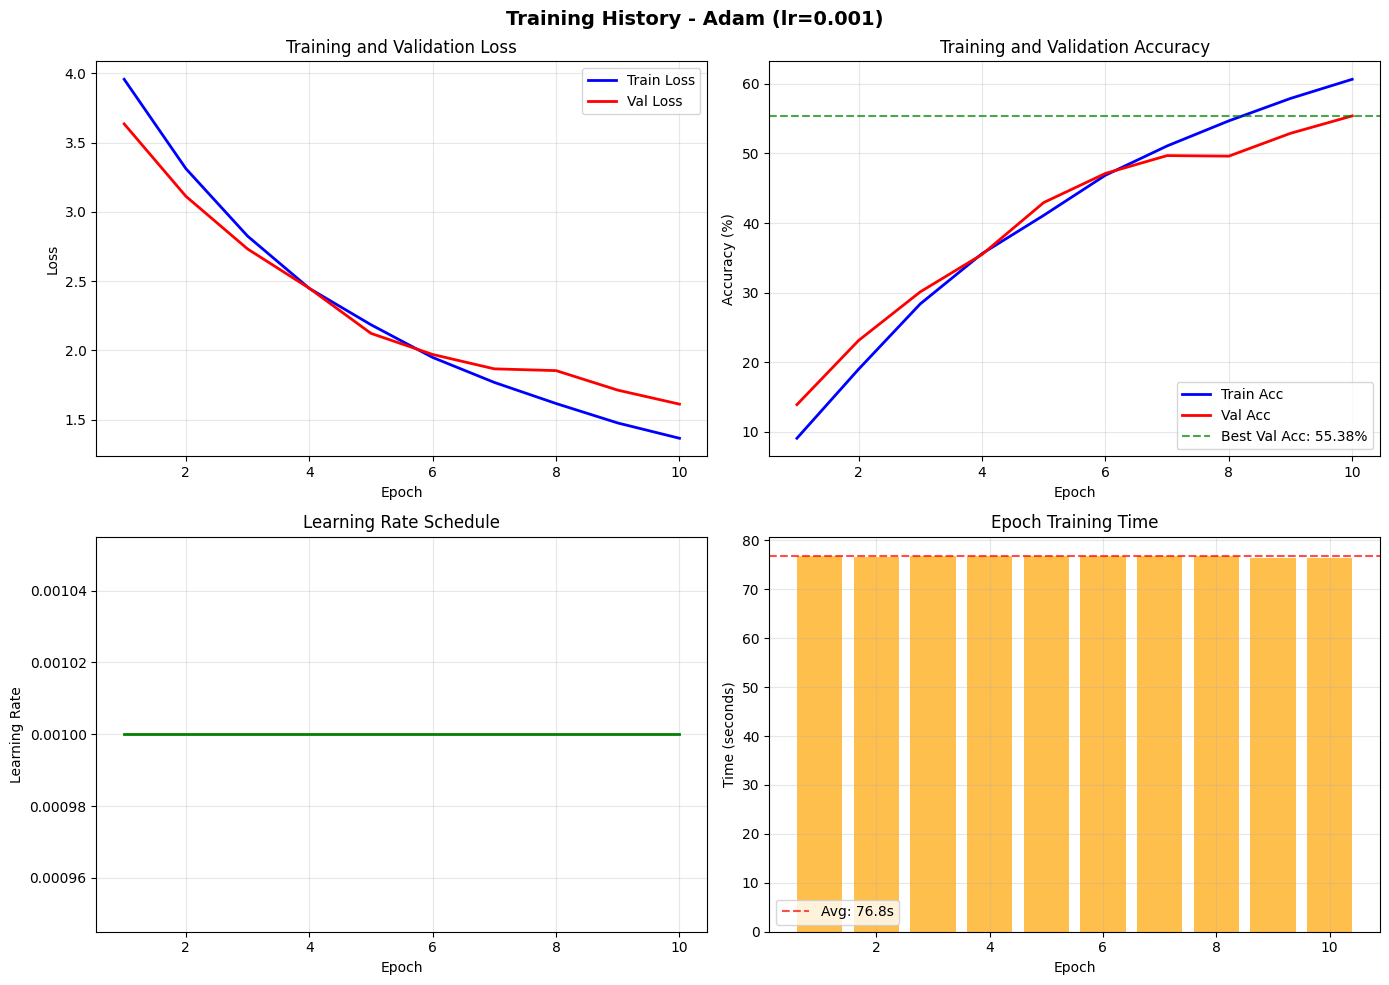


📊 Adam Experiment Complete!
----------------------------------------
   Best Val Acc: 55.38%
   Test Acc: 57.61%
   Peak GPU Memory: 1.137 GB
   Total Time: 13.26 minutes


In [11]:
# ============================================
# OPTIMIZER EXPERIMENT 3/6: Adam
# ============================================
# This script trains ResNet-34 on CIFAR-100 using
# Adam (Adaptive Moment Estimation).

# ============================================
# CONFIGURATION
# ============================================
EPOCHS = 10
OPTIMIZER_NAME = 'Adam'
OPTIMIZER_CONFIG = {
    'optimizer_class': optim.Adam,
    'params': {'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-8, 'weight_decay': 0},
    'description': 'Adam adaptive optimizer'
}

# ============================================
# CHECK GPU AND DATALOADERS
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

try:
    train_loader
    val_loader
    test_loader
    print(" DataLoaders loaded successfully!")
except NameError:
    print(" Error: DataLoaders not found!")
    raise

# ============================================
# SET SEED FOR REPRODUCIBILITY
# ============================================
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================
# CREATE FRESH MODEL
# ============================================
print(f"\n STARTING EXPERIMENT: {OPTIMIZER_NAME}")
print("="*60)

model = ResNet34(num_classes=100)
model = model.to(device)
print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

# ============================================
# CREATE OPTIMIZER
# ============================================
optimizer_class = OPTIMIZER_CONFIG['optimizer_class']
optimizer_params = OPTIMIZER_CONFIG['params']
optimizer = optimizer_class(model.parameters(), **optimizer_params)
print(f"Optimizer: {OPTIMIZER_NAME}")
print(f"Parameters: {optimizer_params}")

# ============================================
# LOSS FUNCTION
# ============================================
criterion = nn.CrossEntropyLoss()

# ============================================
# TRAIN THE MODEL
# ============================================
start_time = time.time()

tracker, best_model_state = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    optimizer_name=OPTIMIZER_NAME,
    lr=optimizer_params.get('lr', 0.01),
    save_best=True,
    early_stopping_patience=None
)

total_time = time.time() - start_time

# ============================================
# GET GPU MEMORY USAGE
# ============================================
if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated(device) / 1e9
else:
    peak_memory = 0

# ============================================
# TEST THE BEST MODEL
# ============================================
if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_loss, test_acc = test_model(model, test_loader, criterion, device, tracker)

# ============================================
# SAVE RESULTS
# ============================================
tracker.peak_gpu_memory = peak_memory
tracker.total_training_time = total_time
tracker.test_accuracy = test_acc
tracker.test_loss = test_loss

save_path = f"{OPTIMIZER_NAME}_best_model.pth"
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_name': OPTIMIZER_NAME,
    'test_accuracy': test_acc,
    'best_val_accuracy': tracker.best_val_acc,
    'config': OPTIMIZER_CONFIG
}, save_path)
print(f" Best model saved to: {save_path}")

metrics_path = f"{OPTIMIZER_NAME}_metrics.csv"
save_metrics(tracker, metrics_path)

plot_path = f"{OPTIMIZER_NAME}_training_history.png"
plot_training_history(tracker, save_path=plot_path)

# ============================================
# PRINT SUMMARY
# ============================================
print(f"\n📊 {OPTIMIZER_NAME} Experiment Complete!")
print("-" * 40)
print(f"   Best Val Acc: {tracker.best_val_acc:.2f}%")
print(f"   Test Acc: {test_acc:.2f}%")
print(f"   Peak GPU Memory: {peak_memory:.3f} GB")
print(f"   Total Time: {total_time/60:.2f} minutes")
print("="*60)

adam_result = {
    'tracker': tracker,
    'test_acc': test_acc,
    'peak_memory': peak_memory,
    'total_time': total_time
}

Using device: cuda
 DataLoaders loaded successfully!

 STARTING EXPERIMENT: RMSprop
Model created with 21,328,292 parameters
Optimizer: RMSprop (avec gradient clipping max_norm=1.0)
Parameters: {'lr': 0.0005, 'alpha': 0.9, 'eps': 1e-08, 'weight_decay': 0.0001}

 Starting training with RMSprop
   Learning rate: 0.0005
   Epochs: 10
   Device: cuda
------------------------------------------------------------


Epoch [1/10] Train Loss: 3.9279, Train Acc: 9.48% | Val Loss: 3.6492, Val Acc: 12.94% | Time: 77.3s


 New best model! Validation accuracy: 19.88%
Epoch [2/10] Train Loss: 3.2746, Train Acc: 19.58% | Val Loss: 3.3571, Val Acc: 19.88% | Time: 76.8s


 New best model! Validation accuracy: 27.58%
Epoch [3/10] Train Loss: 2.8493, Train Acc: 27.29% | Val Loss: 2.8128, Val Acc: 27.58% | Time: 76.8s


 New best model! Validation accuracy: 35.14%
Epoch [4/10] Train Loss: 2.4998, Train Acc: 34.34% | Val Loss: 2.4784, Val Acc: 35.14% | Time: 76.4s


...

Epoch [7/10] Train Loss: 1.9082, Train Acc: 47.21% | Val Loss: 2.2578, Val Acc: 41.46% | Time: 76.1s


 New best model! Validation accuracy: 48.94%
Epoch [8/10] Train Loss: 1.7973, Train Acc: 50.22% | Val Loss: 1.8825, Val Acc: 48.94% | Time: 75.8s


Epoch [9/10] Train Loss: 1.6948, Train Acc: 52.63% | Val Loss: 2.0271, Val Acc: 45.84% | Time: 75.9s


Epoch [10/10] Train Loss: 1.6110, Train Acc: 54.91% | Val Loss: 1.9660, Val Acc: 47.82% | Time: 75.7s

📊 TRAINING SUMMARY - RMSprop
Total epochs: 10
Best validation accuracy: 48.94% (Epoch 8)
Final training accuracy: 54.91%
Final validation accuracy: 47.82%
Total training time: 790.21 seconds (13.17 minutes)
Average epoch time: 76.25 seconds
Learning rate: 0.0005

 FINAL TEST EVALUATION



Test Loss: 2.0011
Test Accuracy: 49.09%
Best Validation Accuracy: 48.94%
Test Accuracy vs Best Validation: +0.15%
 Best model saved to: RMSprop_best_model.pth
 Metrics saved to: RMSprop_metrics.csv
 Figure saved to: RMSprop_training_history.png


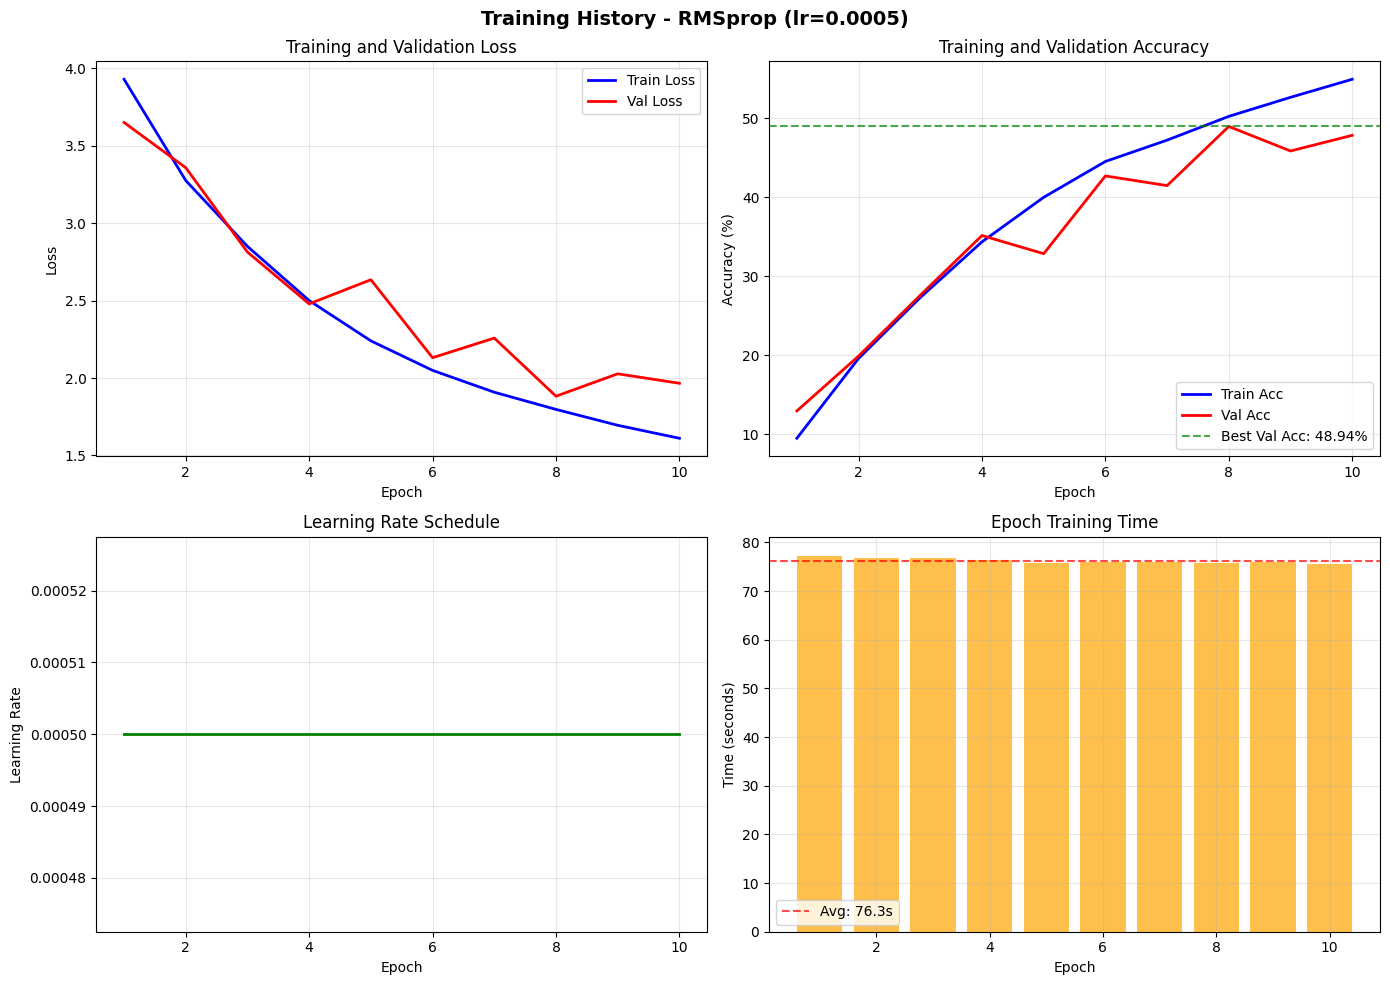


📊 RMSprop Experiment Complete!
----------------------------------------
   Best Val Acc: 48.94%
   Test Acc: 49.09%
   Peak GPU Memory: 1.137 GB
   Total Time: 13.17 minutes


In [12]:
# ============================================
# OPTIMIZER EXPERIMENT 4/6: RMSprop (CORRIGÉ)
# ============================================

# ============================================
# CONFIGURATION
# ============================================
EPOCHS = 10
OPTIMIZER_NAME = 'RMSprop'
OPTIMIZER_CONFIG = {
    'optimizer_class': optim.RMSprop,
    'params': {
        'lr': 0.0005,        # ← MODIFIÉ : était 0.001
        'alpha': 0.9,        # ← MODIFIÉ : était 0.99
        'eps': 1e-8,
        'weight_decay': 1e-4
    },
    'description': 'RMSprop optimizer (stabilisé)'
}

# ============================================
# CHECK GPU ET DATALOADERS
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

try:
    train_loader
    val_loader
    test_loader
    print(" DataLoaders loaded successfully!")
except NameError:
    print(" Error: DataLoaders not found!")
    raise

# ============================================
# SEED
# ============================================
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================
# AJOUTER LE GRADIENT CLIPPING À train_model
# On monkey-patch l'optimiseur pour insérer
# clip_grad_norm_ automatiquement à chaque step
# ============================================
class RMSpropWithClipping(optim.RMSprop):
    """RMSprop avec gradient clipping intégré (max_norm=1.0)"""
    def step(self, closure=None):
        torch.nn.utils.clip_grad_norm_(
            [p for group in self.param_groups for p in group['params']],
            max_norm=1.0
        )
        return super().step(closure)

# ============================================
# MODÈLE + OPTIMISEUR
# ============================================
print(f"\n STARTING EXPERIMENT: {OPTIMIZER_NAME}")
print("="*60)

model = ResNet34(num_classes=100)
model = model.to(device)
print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

# On utilise notre classe corrigée au lieu de optim.RMSprop
optimizer = RMSpropWithClipping(
    model.parameters(),
    **OPTIMIZER_CONFIG['params']
)
print(f"Optimizer: {OPTIMIZER_NAME} (avec gradient clipping max_norm=1.0)")
print(f"Parameters: {OPTIMIZER_CONFIG['params']}")

# ============================================
# LOSS FUNCTION
# ============================================
criterion = nn.CrossEntropyLoss()

# ============================================
# TRAIN THE MODEL  ← exactement comme les autres cellules
# ============================================
start_time = time.time()

tracker, best_model_state = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    optimizer_name=OPTIMIZER_NAME,
    lr=OPTIMIZER_CONFIG['params'].get('lr', 0.01),
    save_best=True,
    early_stopping_patience=None
)

total_time = time.time() - start_time

# ============================================
# GPU MEMORY
# ============================================
if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated(device) / 1e9
else:
    peak_memory = 0

# ============================================
# TEST THE BEST MODEL
# ============================================
if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_loss, test_acc = test_model(model, test_loader, criterion, device, tracker)

# ============================================
# SAVE RESULTS  ← exactement comme les autres cellules
# ============================================
tracker.peak_gpu_memory = peak_memory
tracker.total_training_time = total_time
tracker.test_accuracy = test_acc
tracker.test_loss = test_loss

save_path = f"{OPTIMIZER_NAME}_best_model.pth"
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_name': OPTIMIZER_NAME,
    'test_accuracy': test_acc,
    'best_val_accuracy': tracker.best_val_acc,
    'config': OPTIMIZER_CONFIG
}, save_path)
print(f" Best model saved to: {save_path}")

metrics_path = f"{OPTIMIZER_NAME}_metrics.csv"
save_metrics(tracker, metrics_path)

plot_path = f"{OPTIMIZER_NAME}_training_history.png"
plot_training_history(tracker, save_path=plot_path)   # ← graphes identiques aux autres

# ============================================
# PRINT SUMMARY
# ============================================
print(f"\n📊 {OPTIMIZER_NAME} Experiment Complete!")
print("-" * 40)
print(f"   Best Val Acc: {tracker.best_val_acc:.2f}%")
print(f"   Test Acc: {test_acc:.2f}%")
print(f"   Peak GPU Memory: {peak_memory:.3f} GB")
print(f"   Total Time: {total_time/60:.2f} minutes")
print("="*60)

rmsprop_result = {
    'tracker': tracker,
    'test_acc': test_acc,
    'peak_memory': peak_memory,
    'total_time': total_time
}

Using device: cuda
 DataLoaders loaded successfully!

 STARTING EXPERIMENT: Adagrad
Model created with 21,328,292 parameters
Optimizer: Adagrad
Parameters: {'lr': 0.01, 'lr_decay': 0, 'weight_decay': 0, 'eps': 1e-10}

 Starting training with Adagrad
   Learning rate: 0.01
   Epochs: 10
   Device: cuda
------------------------------------------------------------


Epoch [1/10] Train Loss: 4.0855, Train Acc: 7.08% | Val Loss: 3.7109, Val Acc: 12.54% | Time: 75.8s


 New best model! Validation accuracy: 19.74%
Epoch [2/10] Train Loss: 3.4866, Train Acc: 16.00% | Val Loss: 3.3007, Val Acc: 19.74% | Time: 75.2s


 New best model! Validation accuracy: 25.26%
Epoch [3/10] Train Loss: 3.1030, Train Acc: 23.10% | Val Loss: 2.9914, Val Acc: 25.26% | Time: 75.0s


 New best model! Validation accuracy: 29.90%
Epoch [4/10] Train Loss: 2.8181, Train Acc: 28.56% | Val Loss: 2.7736, Val Acc: 29.90% | Time: 74.8s


...

 New best model! Validation accuracy: 39.14%
Epoch [7/10] Train Loss: 2.2523, Train Acc: 40.40% | Val Loss: 2.3327, Val Acc: 39.14% | Time: 75.5s


 New best model! Validation accuracy: 41.66%
Epoch [8/10] Train Loss: 2.1195, Train Acc: 43.34% | Val Loss: 2.2249, Val Acc: 41.66% | Time: 75.5s


 New best model! Validation accuracy: 43.30%
Epoch [9/10] Train Loss: 1.9960, Train Acc: 46.25% | Val Loss: 2.1109, Val Acc: 43.30% | Time: 75.3s


 New best model! Validation accuracy: 44.98%
Epoch [10/10] Train Loss: 1.8913, Train Acc: 48.60% | Val Loss: 2.0666, Val Acc: 44.98% | Time: 75.6s

📊 TRAINING SUMMARY - Adagrad
Total epochs: 10
Best validation accuracy: 44.98% (Epoch 10)
Final training accuracy: 48.60%
Final validation accuracy: 44.98%
Total training time: 780.66 seconds (13.01 minutes)
Average epoch time: 75.30 seconds
Learning rate: 0.01

 FINAL TEST EVALUATION



Test Loss: 1.9846
Test Accuracy: 47.31%
Best Validation Accuracy: 44.98%
Test Accuracy vs Best Validation: +2.33%
 Best model saved to: Adagrad_best_model.pth
 Metrics saved to: Adagrad_metrics.csv
 Figure saved to: Adagrad_training_history.png


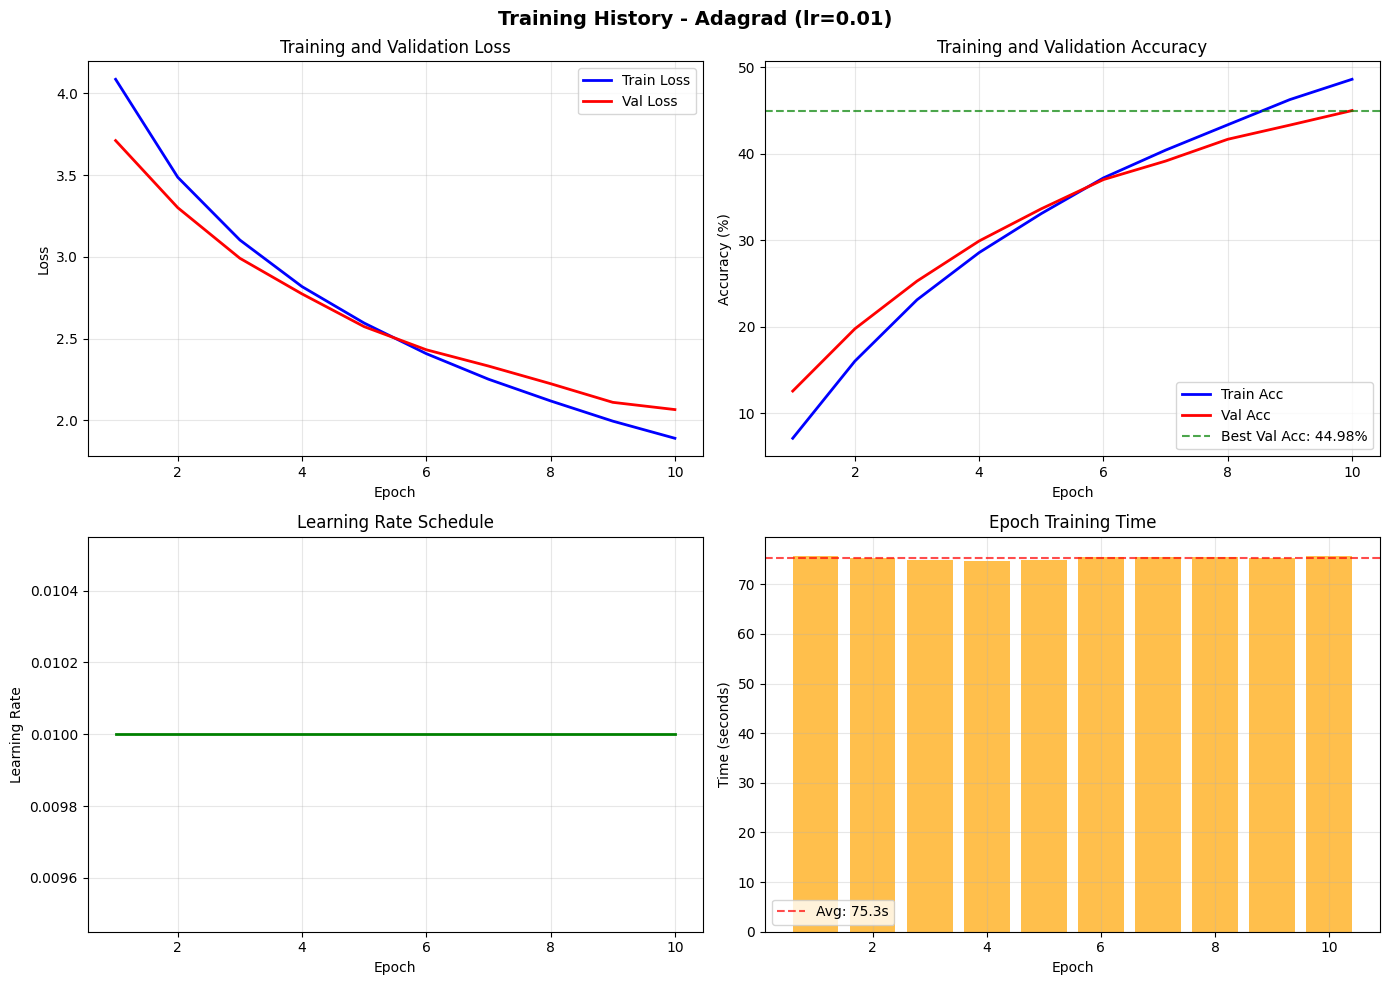


📊 Adagrad Experiment Complete!
----------------------------------------
   Best Val Acc: 44.98%
   Test Acc: 47.31%
   Peak GPU Memory: 1.222 GB
   Total Time: 13.01 minutes


In [13]:
# ============================================
# OPTIMIZER EXPERIMENT 5/6: Adagrad
# ============================================
# This script trains ResNet-34 on CIFAR-100 using
# Adagrad (Adaptive Gradient Algorithm).

# ============================================
# CONFIGURATION
# ============================================
EPOCHS = 10
OPTIMIZER_NAME = 'Adagrad'
OPTIMIZER_CONFIG = {
    'optimizer_class': optim.Adagrad,
    'params': {'lr': 0.01, 'lr_decay': 0, 'weight_decay': 0, 'eps': 1e-10},
    'description': 'Adagrad adaptive optimizer'
}

# ============================================
# CHECK GPU AND DATALOADERS
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

try:
    train_loader
    val_loader
    test_loader
    print(" DataLoaders loaded successfully!")
except NameError:
    print(" Error: DataLoaders not found!")
    raise

# ============================================
# SET SEED FOR REPRODUCIBILITY
# ============================================
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================
# CREATE FRESH MODEL
# ============================================
print(f"\n STARTING EXPERIMENT: {OPTIMIZER_NAME}")
print("="*60)

model = ResNet34(num_classes=100)
model = model.to(device)
print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

# ============================================
# CREATE OPTIMIZER
# ============================================
optimizer_class = OPTIMIZER_CONFIG['optimizer_class']
optimizer_params = OPTIMIZER_CONFIG['params']
optimizer = optimizer_class(model.parameters(), **optimizer_params)
print(f"Optimizer: {OPTIMIZER_NAME}")
print(f"Parameters: {optimizer_params}")

# ============================================
# LOSS FUNCTION
# ============================================
criterion = nn.CrossEntropyLoss()

# ============================================
# TRAIN THE MODEL
# ============================================
start_time = time.time()

tracker, best_model_state = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    optimizer_name=OPTIMIZER_NAME,
    lr=optimizer_params.get('lr', 0.01),
    save_best=True,
    early_stopping_patience=None
)

total_time = time.time() - start_time

# ============================================
# GET GPU MEMORY USAGE
# ============================================
if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated(device) / 1e9
else:
    peak_memory = 0

# ============================================
# TEST THE BEST MODEL
# ============================================
if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_loss, test_acc = test_model(model, test_loader, criterion, device, tracker)

# ============================================
# SAVE RESULTS
# ============================================
tracker.peak_gpu_memory = peak_memory
tracker.total_training_time = total_time
tracker.test_accuracy = test_acc
tracker.test_loss = test_loss

save_path = f"{OPTIMIZER_NAME}_best_model.pth"
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_name': OPTIMIZER_NAME,
    'test_accuracy': test_acc,
    'best_val_accuracy': tracker.best_val_acc,
    'config': OPTIMIZER_CONFIG
}, save_path)
print(f" Best model saved to: {save_path}")

metrics_path = f"{OPTIMIZER_NAME}_metrics.csv"
save_metrics(tracker, metrics_path)

plot_path = f"{OPTIMIZER_NAME}_training_history.png"
plot_training_history(tracker, save_path=plot_path)

# ============================================
# PRINT SUMMARY
# ============================================
print(f"\n📊 {OPTIMIZER_NAME} Experiment Complete!")
print("-" * 40)
print(f"   Best Val Acc: {tracker.best_val_acc:.2f}%")
print(f"   Test Acc: {test_acc:.2f}%")
print(f"   Peak GPU Memory: {peak_memory:.3f} GB")
print(f"   Total Time: {total_time/60:.2f} minutes")
print("="*60)

adagrad_result = {
    'tracker': tracker,
    'test_acc': test_acc,
    'peak_memory': peak_memory,
    'total_time': total_time
}

 NAdam natif PyTorch chargé avec succès!
Using device: cuda
 DataLoaders loaded successfully!

 STARTING EXPERIMENT: Nadam
Model created with 21,328,292 parameters
Optimizer: Nadam
Parameters: {'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.0001}

 Starting training with Nadam
   Learning rate: 0.001
   Epochs: 10
   Device: cuda
------------------------------------------------------------


Epoch [1/10] Train Loss: 3.9203, Train Acc: 9.39% | Val Loss: 3.7094, Val Acc: 13.28% | Time: 78.8s


 New best model! Validation accuracy: 19.94%
Epoch [2/10] Train Loss: 3.2874, Train Acc: 19.20% | Val Loss: 3.3728, Val Acc: 19.94% | Time: 78.4s


 New best model! Validation accuracy: 25.22%
Epoch [3/10] Train Loss: 2.8093, Train Acc: 27.82% | Val Loss: 3.0011, Val Acc: 25.22% | Time: 78.4s


 New best model! Validation accuracy: 35.72%
Epoch [4/10] Train Loss: 2.4537, Train Acc: 35.26% | Val Loss: 2.4439, Val Acc: 35.72% | Time: 77.7s


...

 New best model! Validation accuracy: 46.02%
Epoch [7/10] Train Loss: 1.8355, Train Acc: 49.17% | Val Loss: 1.9992, Val Acc: 46.02% | Time: 77.0s


 New best model! Validation accuracy: 47.28%
Epoch [8/10] Train Loss: 1.7303, Train Acc: 51.53% | Val Loss: 1.9387, Val Acc: 47.28% | Time: 76.7s


 New best model! Validation accuracy: 50.06%
Epoch [9/10] Train Loss: 1.6394, Train Acc: 53.88% | Val Loss: 1.8019, Val Acc: 50.06% | Time: 76.7s


 New best model! Validation accuracy: 51.04%
Epoch [10/10] Train Loss: 1.5758, Train Acc: 55.53% | Val Loss: 1.7488, Val Acc: 51.04% | Time: 76.7s

📊 TRAINING SUMMARY - Nadam
Total epochs: 10
Best validation accuracy: 51.04% (Epoch 10)
Final training accuracy: 55.53%
Final validation accuracy: 51.04%
Total training time: 803.08 seconds (13.38 minutes)
Average epoch time: 77.45 seconds
Learning rate: 0.001

 FINAL TEST EVALUATION



Test Loss: 1.7533
Test Accuracy: 51.45%
Best Validation Accuracy: 51.04%
Test Accuracy vs Best Validation: +0.41%
 Best model saved to: Nadam_best_model.pth
 Metrics saved to: Nadam_metrics.csv
 Figure saved to: Nadam_training_history.png


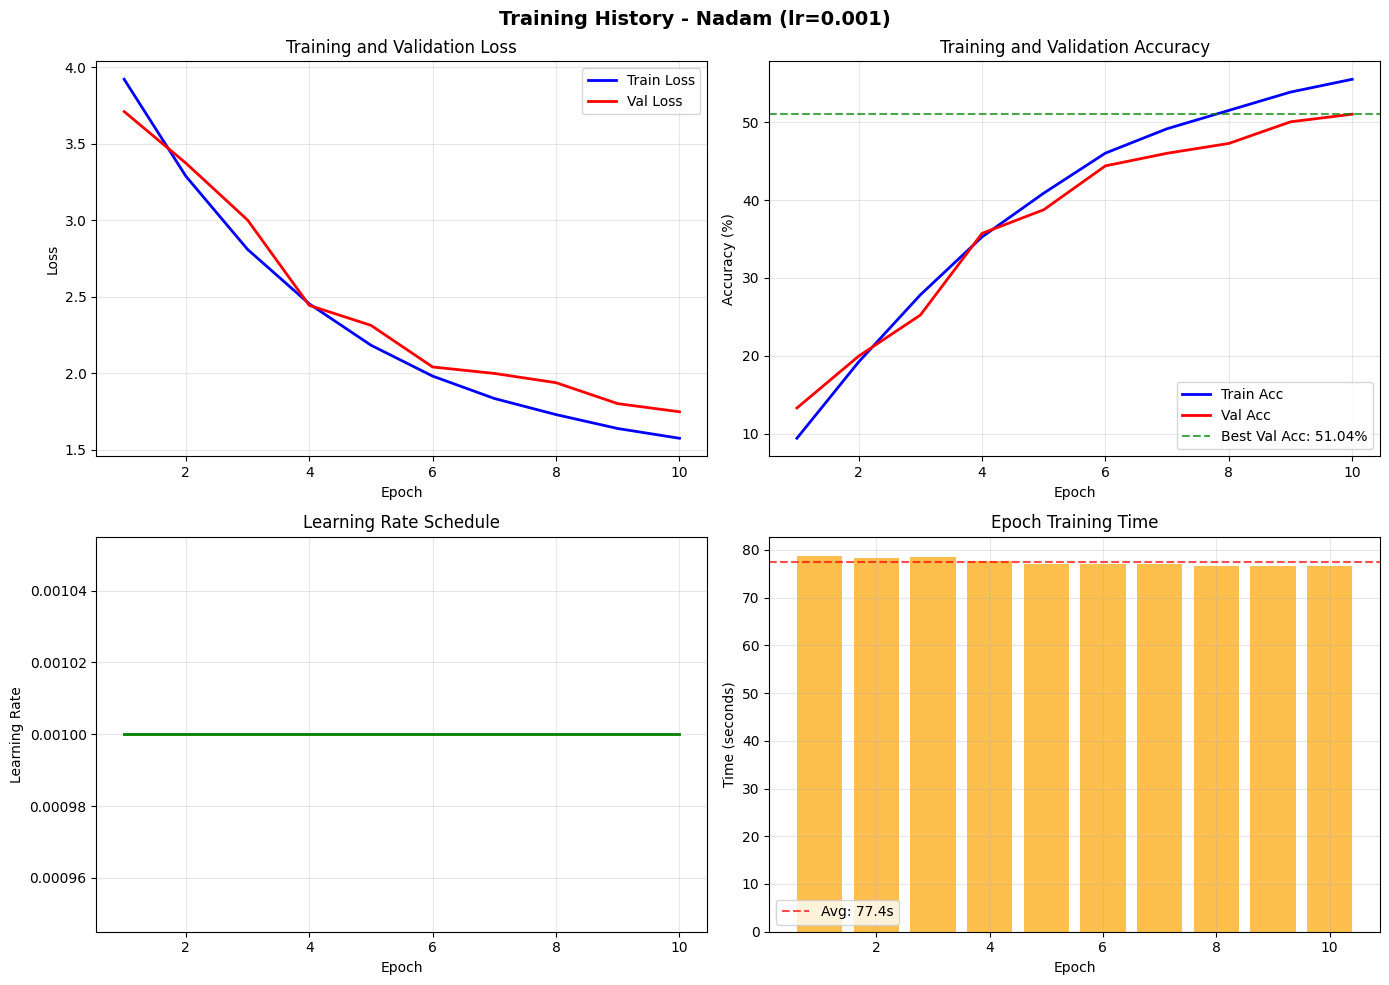


📊 Nadam Experiment Complete!
----------------------------------------
   Best Val Acc : 51.04%
   Test Acc     : 51.45%
   Peak GPU Mem : 1.393 GB
   Total Time   : 13.38 minutes


In [14]:
# ============================================
# OPTIMIZER EXPERIMENT 6/6: NAdam (CORRIGÉ)
# ============================================
# Correction : utilisation de torch.optim.NAdam
# (N majuscule) natif PyTorch 2.x au lieu du
# fallback manuel qui causait le spike epoch 9

# ============================================
# CHARGEMENT DE NAdam NATIF
# ============================================
try:
    NadamOptimizer = optim.NAdam          # ← N majuscule : natif PyTorch 2.x
    print(" NAdam natif PyTorch chargé avec succès!")
except AttributeError:
    # Garde-fou au cas où la version PyTorch serait très ancienne
    print("  NAdam non disponible, utilisation du fallback corrigé")

    class NadamOptimizer(optim.Optimizer):
        """Fallback NAdam avec correction de Nesterov correcte"""
        def __init__(self, params, lr=0.001, betas=(0.9, 0.999),
                     eps=1e-8, weight_decay=0):
            defaults = dict(lr=lr, betas=betas, eps=eps,
                            weight_decay=weight_decay)
            super().__init__(params, defaults)

        def step(self, closure=None):
            loss = None
            if closure is not None:
                loss = closure()
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue
                    grad = p.grad.data
                    if group['weight_decay'] != 0:
                        grad = grad.add(p.data,
                                        alpha=group['weight_decay'])
                    state = self.state[p]
                    if len(state) == 0:
                        state['step'] = 0
                        state['m'] = torch.zeros_like(p.data)
                        state['v'] = torch.zeros_like(p.data)
                    m, v = state['m'], state['v']
                    beta1, beta2 = group['betas']
                    state['step'] += 1
                    t = state['step']

                    m.mul_(beta1).add_(grad, alpha=1 - beta1)
                    v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                    # Correction de biais
                    m_hat = m / (1 - beta1 ** t)
                    v_hat = v / (1 - beta2 ** t)

                    # Correction de Nesterov (terme clé manquant dans l'ancien fallback)
                    nesterov_m = (beta1 * m_hat +
                                  (1 - beta1) * grad / (1 - beta1 ** t))

                    p.data.addcdiv_(nesterov_m, v_hat.sqrt().add_(group['eps']),
                                    value=-group['lr'])
            return loss

    print(" Fallback NAdam corrigé créé!")

# ============================================
# CONFIGURATION
# ============================================
EPOCHS = 10
OPTIMIZER_NAME = 'Nadam'
OPTIMIZER_CONFIG = {
    'optimizer_class': NadamOptimizer,
    'params': {
        'lr': 0.001,                   # ← réduit de 0.002 à 0.001 (aligné sur Adam)
        'betas': (0.9, 0.999),
        'eps': 1e-8,
        'weight_decay': 1e-4           # ← ajouté pour cohérence avec les autres
    },
    'description': 'NAdam natif PyTorch (Nesterov Adam)'
}

# ============================================
# CHECK GPU ET DATALOADERS
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("="*60)

try:
    train_loader
    val_loader
    test_loader
    print(" DataLoaders loaded successfully!")
except NameError:
    print(" Error: DataLoaders not found!")
    raise

# ============================================
# SEED
# ============================================
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================
# MODÈLE
# ============================================
print(f"\n STARTING EXPERIMENT: {OPTIMIZER_NAME}")
print("="*60)

model = ResNet34(num_classes=100)
model = model.to(device)
print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

# ============================================
# OPTIMISEUR
# ============================================
optimizer_class = OPTIMIZER_CONFIG['optimizer_class']
optimizer_params = OPTIMIZER_CONFIG['params']
optimizer = optimizer_class(model.parameters(), **optimizer_params)
print(f"Optimizer: {OPTIMIZER_NAME}")
print(f"Parameters: {optimizer_params}")

# ============================================
# LOSS FUNCTION
# ============================================
criterion = nn.CrossEntropyLoss()

# ============================================
# ENTRAÎNEMENT
# ============================================
start_time = time.time()

tracker, best_model_state = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=EPOCHS,
    optimizer_name=OPTIMIZER_NAME,
    lr=optimizer_params.get('lr', 0.01),
    save_best=True,
    early_stopping_patience=None
)

total_time = time.time() - start_time

# ============================================
# GPU MEMORY
# ============================================
if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated(device) / 1e9
else:
    peak_memory = 0

# ============================================
# TEST DU MEILLEUR MODÈLE
# ============================================
if best_model_state is not None:
    model.load_state_dict(best_model_state)

test_loss, test_acc = test_model(model, test_loader, criterion, device, tracker)

# ============================================
# SAUVEGARDE DES RÉSULTATS
# ============================================
tracker.peak_gpu_memory = peak_memory
tracker.total_training_time = total_time
tracker.test_accuracy = test_acc
tracker.test_loss = test_loss

save_path = f"{OPTIMIZER_NAME}_best_model.pth"
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_name': OPTIMIZER_NAME,
    'test_accuracy': test_acc,
    'best_val_accuracy': tracker.best_val_acc,
    'config': OPTIMIZER_CONFIG
}, save_path)
print(f" Best model saved to: {save_path}")

metrics_path = f"{OPTIMIZER_NAME}_metrics.csv"
save_metrics(tracker, metrics_path)

plot_path = f"{OPTIMIZER_NAME}_training_history.png"
plot_training_history(tracker, save_path=plot_path)

# ============================================
# RÉSUMÉ FINAL
# ============================================
print(f"\n📊 {OPTIMIZER_NAME} Experiment Complete!")
print("-" * 40)
print(f"   Best Val Acc : {tracker.best_val_acc:.2f}%")
print(f"   Test Acc     : {test_acc:.2f}%")
print(f"   Peak GPU Mem : {peak_memory:.3f} GB")
print(f"   Total Time   : {total_time/60:.2f} minutes")
print("="*60)

nadam_result = {
    'tracker': tracker,
    'test_acc': test_acc,
    'peak_memory': peak_memory,
    'total_time': total_time
}

📊 COMPARAISON DES OPTIMIZERS (10 EPOCHS, BATCH_SIZE=64)

📈 TABLEAU COMPARATIF
----------------------------------------------------------------------
   Optimizer  Best Val Accuracy (%)  Final Val Accuracy (%)  Test Accuracy (%)  Time (min)  Peak Memory (GB)  Epochs
        Adam                  55.38                   55.38              57.61       13.26             1.137      10
       Nadam                  51.04                   51.04              51.45       13.38             1.393      10
     RMSprop                  48.94                   47.82              49.09       13.17             1.137      10
     Adagrad                  44.98                   44.98              47.31       13.01             1.222      10
SGD_Momentum                  38.60                   38.60              39.60       12.90             0.963      10
         SGD                  13.10                   13.10              12.79       12.75             0.784      10

💾 Sauvegardé dans 'comparison_1

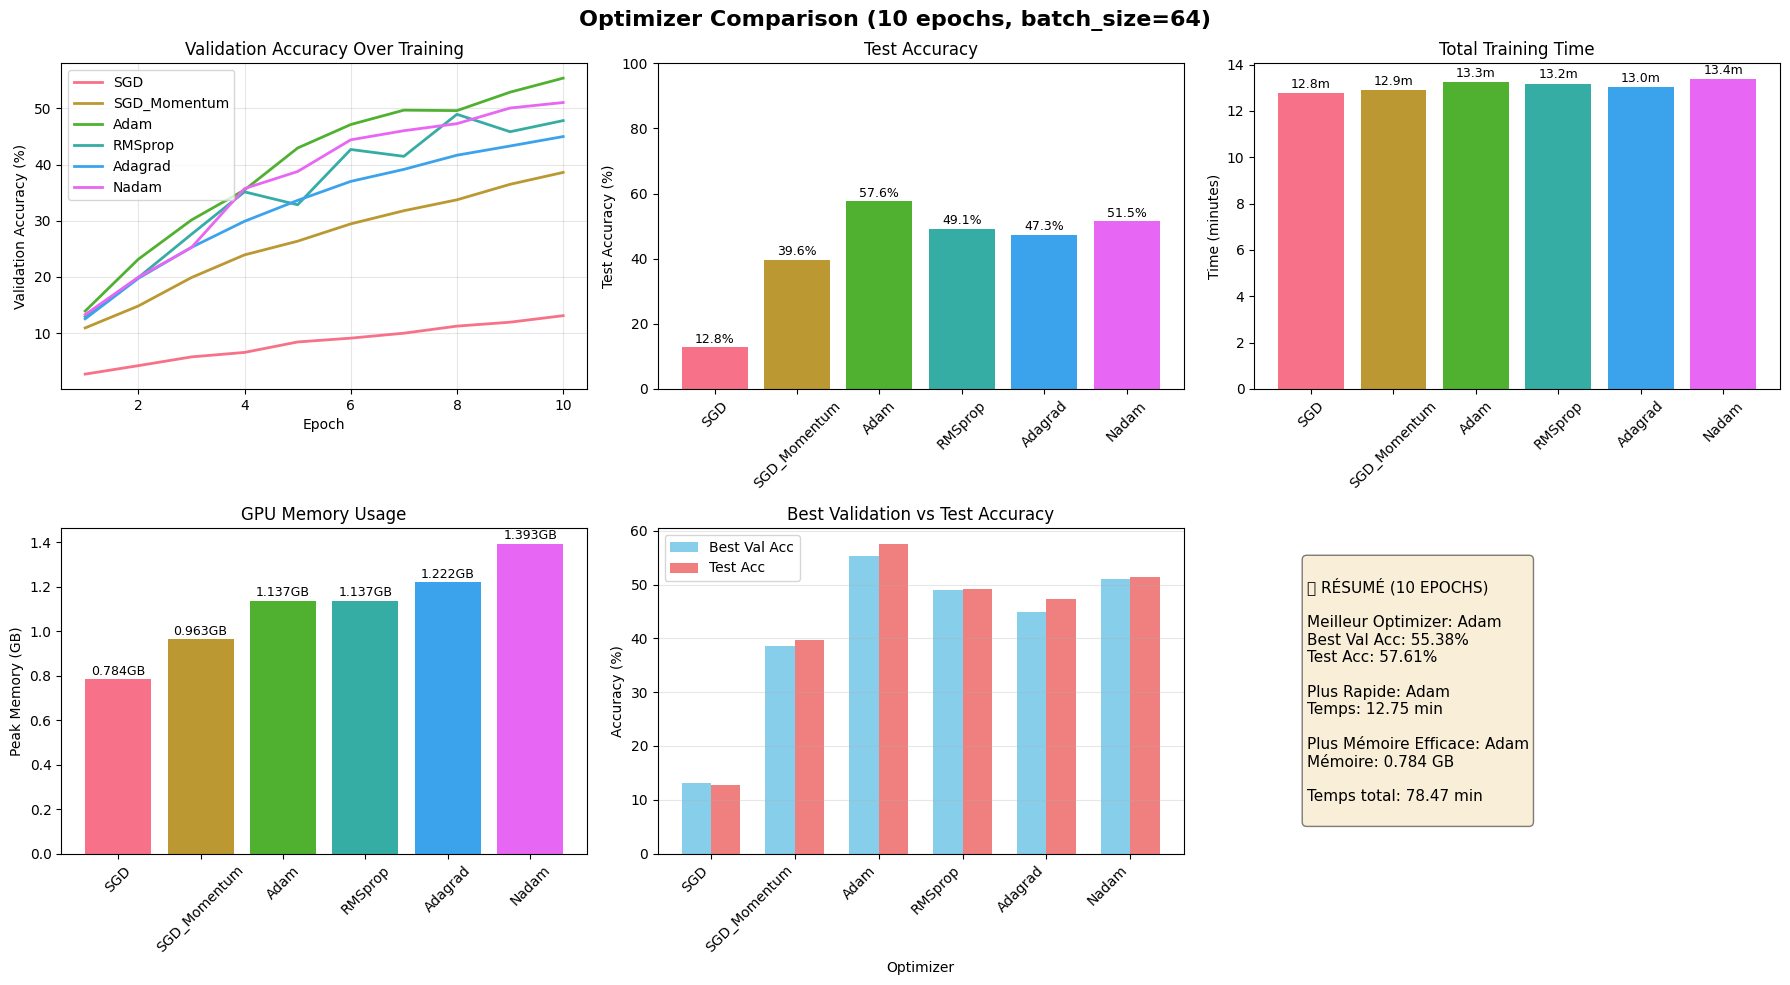


📊 STATISTIQUES DÉTAILLÉES

🏆 TOP 3 OPTIMIZERS - BEST VALIDATION ACCURACY:
Optimizer  Best Val Accuracy (%)  Test Accuracy (%)
     Adam                  55.38              57.61
    Nadam                  51.04              51.45
  RMSprop                  48.94              49.09

⏱️ TOP 3 OPTIMIZERS - FASTEST TRAINING:
   Optimizer  Time (min)
         SGD       12.75
SGD_Momentum       12.90
     Adagrad       13.01

💾 TOP 3 OPTIMIZERS - MOST MEMORY EFFICIENT:
   Optimizer  Peak Memory (GB)
         SGD             0.784
SGD_Momentum             0.963
        Adam             1.137

📈 OPTIMIZER RANKING SUMMARY:
--------------------------------------------------
   Optimizer  Best Val Accuracy (%)  Test Accuracy (%)  Time (min)  Peak Memory (GB)
        Adam                  55.38              57.61       13.26             1.137
       Nadam                  51.04              51.45       13.38             1.393
     RMSprop                  48.94              49.09       13.17     

In [15]:
# ============================================
# FINAL: COMPARE ALL OPTIMIZER RESULTS
# ============================================
# This script loads all results and generates
# comparative analysis and visualizations.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("📊 COMPARAISON DES OPTIMIZERS (10 EPOCHS, BATCH_SIZE=64)")
print("="*70)

# ============================================
# 1. COLLECT ALL RESULTS
# ============================================
# Assurez-vous que ces variables existent
# Si certains optimizers n'ont pas été exécutés, commentez-les

all_results = {
    'SGD': sgd_result,
    'SGD_Momentum': sgd_momentum_result,
    'Adam': adam_result,
    'RMSprop': rmsprop_result,
    'Adagrad': adagrad_result,
    'Nadam': nadam_result
}

# ============================================
# 2. CREATE COMPARISON TABLE
# ============================================
comparison_data = []
for opt_name, result in all_results.items():
    tracker = result['tracker']
    data = {
        'Optimizer': opt_name,
        'Best Val Accuracy (%)': round(tracker.best_val_acc, 2),
        'Final Val Accuracy (%)': round(tracker.val_acc[-1], 2) if tracker.val_acc else 0,
        'Test Accuracy (%)': round(result['test_acc'], 2),
        'Time (min)': round(result['total_time'] / 60, 2),
        'Peak Memory (GB)': round(result['peak_memory'], 3),
        'Epochs': len(tracker.train_loss)
    }
    comparison_data.append(data)

# Créer DataFrame
df = pd.DataFrame(comparison_data)
df = df.sort_values('Best Val Accuracy (%)', ascending=False)

print("\n📈 TABLEAU COMPARATIF")
print("-" * 70)
print(df.to_string(index=False))

# Sauvegarder
df.to_csv('comparison_10_epochs.csv', index=False)
print("\n💾 Sauvegardé dans 'comparison_10_epochs.csv'")

# ============================================
# 3. VISUALISATION
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Optimizer Comparison (10 epochs, batch_size=64)',
             fontsize=16, fontweight='bold')

# Color palette
colors = sns.color_palette("husl", len(all_results))

# Plot 1: Validation Accuracy
ax = axes[0, 0]
for idx, (opt_name, result) in enumerate(all_results.items()):
    tracker = result['tracker']
    epochs = range(1, len(tracker.val_acc) + 1)
    ax.plot(epochs, tracker.val_acc, label=opt_name,
            color=colors[idx], linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Validation Accuracy Over Training')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Test Accuracy
ax = axes[0, 1]
opt_names = list(all_results.keys())
test_accs = [result['test_acc'] for result in all_results.values()]
bars = ax.bar(opt_names, test_accs, color=colors)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy')
ax.set_ylim(0, 100)
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=45)

# Plot 3: Training Time
ax = axes[0, 2]
times = [result['total_time'] / 60 for result in all_results.values()]
bars = ax.bar(opt_names, times, color=colors)
ax.set_ylabel('Time (minutes)')
ax.set_title('Total Training Time')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{t:.1f}m', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=45)

# Plot 4: GPU Memory
ax = axes[1, 0]
memory = [result['peak_memory'] for result in all_results.values()]
bars = ax.bar(opt_names, memory, color=colors)
ax.set_ylabel('Peak Memory (GB)')
ax.set_title('GPU Memory Usage')
for bar, m in zip(bars, memory):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{m:.3f}GB', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=45)

# Plot 5: Best Val vs Test Accuracy
ax = axes[1, 1]
best_val = [result['tracker'].best_val_acc for result in all_results.values()]
x = np.arange(len(opt_names))
width = 0.35
ax.bar(x - width/2, best_val, width, label='Best Val Acc', color='skyblue')
ax.bar(x + width/2, test_accs, width, label='Test Acc', color='lightcoral')
ax.set_xlabel('Optimizer')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Best Validation vs Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(opt_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 6: Summary
ax = axes[1, 2]
ax.axis('off')
summary_text = f"""
📊 RÉSUMÉ (10 EPOCHS)

Meilleur Optimizer: {df.iloc[0]['Optimizer']}
Best Val Acc: {df.iloc[0]['Best Val Accuracy (%)']}%
Test Acc: {df.iloc[0]['Test Accuracy (%)']}%

Plus Rapide: {df.iloc[df['Time (min)'].idxmin()]['Optimizer']}
Temps: {df['Time (min)'].min():.2f} min

Plus Mémoire Efficace: {df.iloc[df['Peak Memory (GB)'].idxmin()]['Optimizer']}
Mémoire: {df['Peak Memory (GB)'].min():.3f} GB

Temps total: {df['Time (min)'].sum():.2f} min
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('optimizer_comparison_10_epochs.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 4. STATISTIQUES DÉTAILLÉES
# ============================================
print("\n" + "="*70)
print("📊 STATISTIQUES DÉTAILLÉES")
print("="*70)

print("\n🏆 TOP 3 OPTIMIZERS - BEST VALIDATION ACCURACY:")
print(df[['Optimizer', 'Best Val Accuracy (%)', 'Test Accuracy (%)']].head(3).to_string(index=False))

print("\n⏱️ TOP 3 OPTIMIZERS - FASTEST TRAINING:")
print(df[['Optimizer', 'Time (min)']].nsmallest(3, 'Time (min)').to_string(index=False))

print("\n💾 TOP 3 OPTIMIZERS - MOST MEMORY EFFICIENT:")
print(df[['Optimizer', 'Peak Memory (GB)']].nsmallest(3, 'Peak Memory (GB)').to_string(index=False))

print("\n📈 OPTIMIZER RANKING SUMMARY:")
print("-" * 50)
rankings = df[['Optimizer', 'Best Val Accuracy (%)', 'Test Accuracy (%)', 'Time (min)', 'Peak Memory (GB)']]
print(rankings.to_string(index=False))

print("\n" + "="*70)
print("🏆 COMPARAISON TERMINÉE!")
print("="*70)